# **Fichier d'analyse des résulats**

## Chargement librairies etc

In [324]:
import pandas as pd
import json

import matplotlib.pyplot as plt
from matplotlib import font_manager
import os


In [325]:
# Paramètres pour les graphiques
font_dir = "assets"

for file in os.listdir(font_dir):
    if file.endswith(".ttf"):
        font_manager.fontManager.addfont(os.path.join(font_dir, file))

plt.rcParams["font.family"] = "Marianne"
plt.rcParams.update({
    "font.family": "Marianne",

    "axes.titlesize": 16,
    "axes.titleweight": "bold",

    "figure.titlesize": 18,
    "figure.titleweight": "bold",

    "axes.labelsize": 12,
    "axes.labelweight": "regular",

    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "legend.fontsize": 10,
})

# Colors and styles for plotting
palette = {
    "Solar":      "#d66b0d",
    "Hydro":        "#2672b0",
    "Onshore":      "#72cbb7",
    "Offshore":     "#4d8377",
    "H2_CCG":       "#e4a701",
    "H2_TAC":       "#f0c040",
    "STEP_charge":  "#7a1616",
    "Fond":         "#ffffff",
    "STEP_discharge": "#ff0000",
    "Battery_charge": "#4B1063",
    "Battery_discharge": "#d126c9",
    "Battery" : "#8226A7",
    "hy_th_fatal": "#0C2DEB",
    "Electrolyse": "#e27c9a",
}

# Colonnes production (positives)
prod_cols = [
    'hy_th_fatal','H2_CCG','H2_TAC','Hydro','Onshore','Offshore',
        'STEP_discharge','Battery_discharge','Solar'
]

# Colonnes charge
charge_cols = [
    'STEP_charge','Battery_charge', 'Electrolyse'
]

## __0. Lecture des données__

In [326]:
# Config de lecture des données
WEEK_TARGET = 0  # semaine de départ
TWO_WEEKS = True   # True pour 2 semaines, False pour 1 semaine

id1 = "ACC8BA95"
id2 = "D8B55459"

name_simu_1 = "Simu 1"
name_simu_2 = "Simu 2"

**Lecture : *base_de_données_résultats.csv***

In [327]:


# -----------------------------
# 1️Lecture du CSV
# -----------------------------
df_db = pd.read_csv(os.path.join("results",
    "base_de_données_résultats.csv"),
    sep=";"   # important car ton fichier est séparé par ;
)
# -----------------------------
# Filtrage
# -----------------------------
df_selected = df_db[df_db["ID"].isin([id1, id2])]

# -----------------------------
# Création des variables
# -----------------------------
for _, row in df_selected.iterrows():
    
    prefix = row["ID"]
    
    globals()[f"H2_ANNUAL_STOCK_{prefix}"] = row["H2_ANNUAL_STOCK"]
    globals()[f"H2_NO_LIMIT_{prefix}"] = row["H2_NO_LIMIT"]
    globals()[f"GISEMENTS_{prefix}"] = row["GISEMENTS"]
    globals()[f"HYDRO_STOCK_REMAINING_{prefix}"] = row["HYDRO_STOCK_REMAINING"]
    globals()[f"FIRST_WEEK_{prefix}"] = row["FIRST_WEEK"]

# -----------------------------
# Affichage du tableau
# -----------------------------
print("Paramètres récupérés :")
print(df_selected)

Paramètres récupérés :
         ID  H2_ANNUAL_STOCK  H2_NO_LIMIT  GISEMENTS  HYDRO_STOCK_REMAINING  \
0  ACC8BA95             True        False       True                   True   
5  D8B55459             True        False       True                   True   

   FIRST_WEEK  Comment  
0          40      NaN  
5           1      NaN  


### **Chargement données**

**Données des simulations** 

In [328]:
# =====================================================
# =================== SIMU 1 ====================
# =====================================================

# --- Chargement des données ---
df_global1 = pd.read_csv(f"results/{id1}/results.csv", sep=';')
parc_annuel1 = json.load(open(f"results/{id1}/parc_annuel.json", "r"))
evolution_parc1 = json.load(open(f"results/{id1}/evolution_parc.json", "r"))

# --- Récupération de la première semaine simulée ---
results = pd.read_csv("results/base_de_données_résultats.csv", sep=';')
first_week_sim1 = results[results['ID'] == id1]['FIRST_WEEK'].values[0]

# --- Calcul du décalage en heures ---
shift_hours1 = (first_week_sim1 - 1) * 7 * 24

# --- Recalage des données ---
df_global1 = pd.concat([
    df_global1.iloc[shift_hours1:],
    df_global1.iloc[:shift_hours1]
]).reset_index(drop=True)

# --- Recréation index temporel ---
df_global1["t"] = range(len(df_global1))
df_global1.set_index("t", inplace=True)

# --- Extraction des semaines ---
num_weeks_to_plot = 2 if TWO_WEEKS else 1
start_idx = WEEK_TARGET * 7 * 24
end_idx = start_idx + num_weeks_to_plot * 7 * 24

df1 = df_global1.iloc[start_idx:end_idx].copy()


# =====================================================
# =================== SIMU 2 ====================
# =====================================================

# --- Chargement des données ---
df_global2 = pd.read_csv(f"results/{id2}/results.csv", sep=';')
parc_annuel2 = json.load(open(f"results/{id2}/parc_annuel.json", "r"))
evolution_parc2 = json.load(open(f"results/{id2}/evolution_parc.json", "r"))

# --- Récupération de la première semaine simulée ---
first_week_sim2 = results[results['ID'] == id2]['FIRST_WEEK'].values[0]

# --- Calcul du décalage en heures ---
shift_hours2 = (first_week_sim2 - 1) * 7 * 24

# --- Recalage des données ---
df_global2 = pd.concat([
    df_global2.iloc[shift_hours2:],
    df_global2.iloc[:shift_hours2]
]).reset_index(drop=True)

# --- Recréation index temporel ---
df_global2["t"] = range(len(df_global2))
df_global2.set_index("t", inplace=True)

# --- Extraction des semaines ---
df2 = df_global2.iloc[start_idx:end_idx].copy()

**Données du fichier excel**

In [329]:
import os
from utils.extraction_donnees_excel import extraire_donnees_config

# Chemin vers le fichier Excel
excel_path = os.path.join("data", "Donnees_etude_de_cas_ETE305.xlsx")

# Extraction de la configuration depuis Excel
config = extraire_donnees_config(excel_path)



# ==============================
# --- EnR / CAPEX / OPEX / Durée de vie ---
# ==============================
capex_onshore = config["enr"]["onshore"]["capex"]          # €/MW
opex_onshore = config["enr"]["onshore"]["opex"]            # €/MW/year
d_onshore = config["enr"]["onshore"]["duree_vie"]         # années

capex_offshore = config["enr"]["offshore_pose"]["capex"]
opex_offshore = config["enr"]["offshore_pose"]["opex"]
d_offshore = config["enr"]["offshore_pose"]["duree_vie"]

capex_pv = config["enr"]["pv_pose"]["capex"]
opex_pv = config["enr"]["pv_pose"]["opex"]
d_pv = config["enr"]["pv_pose"]["duree_vie"]

capex_CCG_H2 = config["enr"]["CCG_H2"]["capex"]
opex_CCG_H2 = config["enr"]["CCG_H2"]["opex"]
d_CCG_H2 = config["enr"]["CCG_H2"]["duree_vie"]

capex_TAC_H2 = config["enr"]["TAC_H2"]["capex"]
opex_TAC_H2 = config["enr"]["TAC_H2"]["opex"]
d_TAC_H2 = config["enr"]["TAC_H2"]["duree_vie"]

capex_electrolyzer = config["electrolyzer"]["capex"]
opex_electrolyzer = config["electrolyzer"]["opex"]
d_electrolyzer = config["electrolyzer"]["duree_vie"]

capex_battery = config["battery"]["capex"]
opex_battery = config["battery"]["opex"]
d_battery = config["battery"]["duree_vie"]
rendement_battery = config["battery"]["rendement"]
d_battery_max = config["battery"]["d_battery"]
CapaBattery_init = config["battery"]["CapaBattery_init"]
gisement_battery = config["battery"]["gisement"]

# ==============================
# --- H2 ---
# ==============================
# CCG
PU_cost_CCG = config["H2"]["CCG"]["PU_cost"]
Pmin_CCG = config["H2"]["CCG"]["Pmin"]
Pmax_CCG = config["H2"]["CCG"]["Pmax"]
dmin_CCG = config["H2"]["CCG"]["dmin"]
gisement_CCG = config["H2"]["CCG"]["gisement"]

# TAC
PU_cost_TAC = config["H2"]["TAC"]["PU_cost"]
Pmin_TAC = config["H2"]["TAC"]["Pmin"]
Pmax_TAC = config["H2"]["TAC"]["Pmax"]
dmin_TAC = config["H2"]["TAC"]["dmin"]
gisement_TAC = config["H2"]["TAC"]["gisement"]

# ==============================
# --- Hydro ---
# ==============================
Pmax_lacs = config["hydro"]["lacs"]["Pmax"]
Pmax_STEP = config["hydro"]["STEP"]["Pmax"]
rendement_pompage_STEP = config["hydro"]["STEP"]["rendement_pompage"]

# ==============================
# --- Défaillance ---
# ==============================
cost_unsupplied = config["defaillance"]["cost_unsupplied"]
cost_excess = config["defaillance"]["cost_excess"]

# ==============================
# --- Rendements ---
# ==============================
rendement_electrolyse = config["rendements"]["electrolyse"]
rendement_combustion = config["rendements"]["combustion"]

# ==============================
# --- Gisements ---
# ==============================
gisement_solar = config["enr"]["gisement"]["Solar"]
gisement_onshore = config["enr"]["gisement"]["Onshore"]
gisement_offshore = config["enr"]["gisement"]["Offshore"]

## **1. EOD : vue générale**

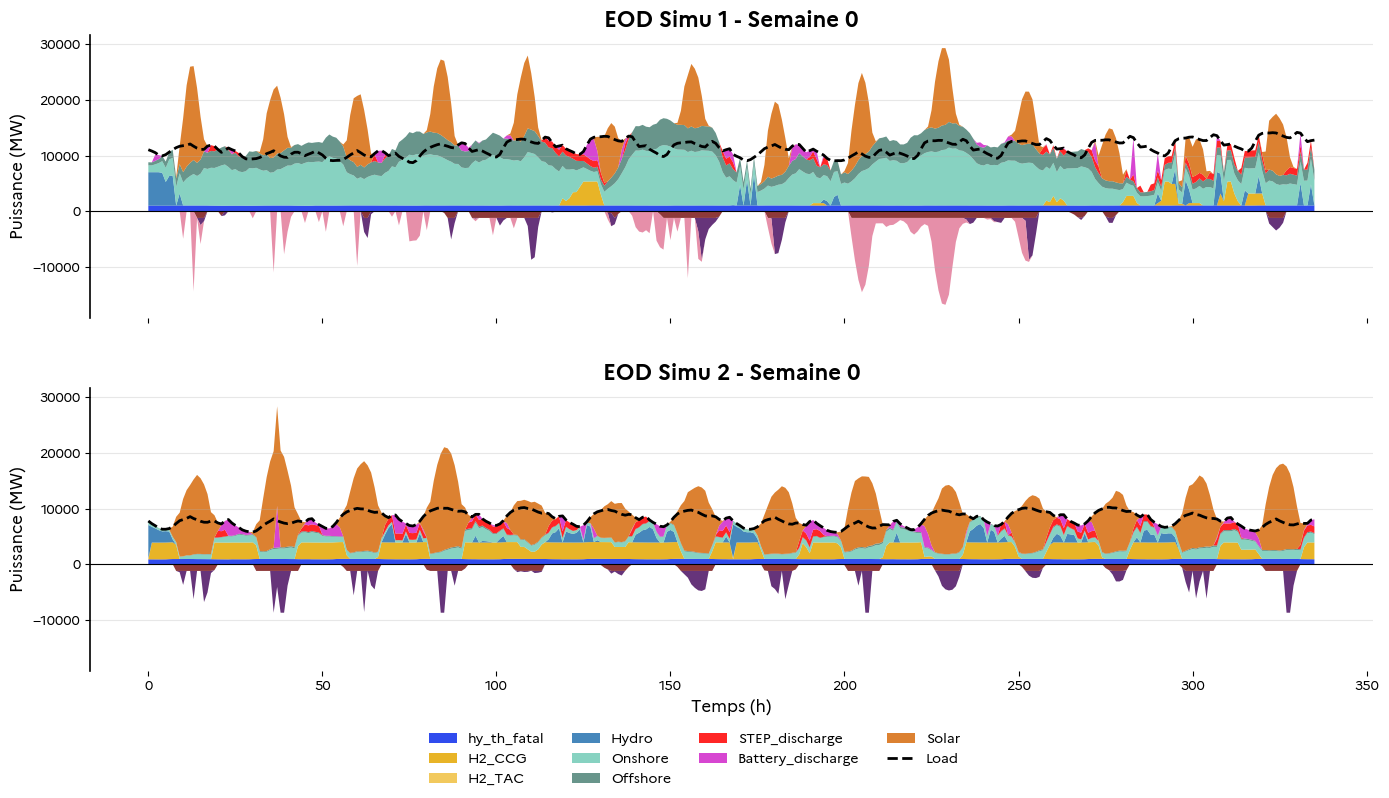

In [337]:
fig, axes = plt.subplots(
    nrows=2, ncols=1,
    figsize=(14,8),
    sharex=True,
    sharey=True
)

# =====================================================
# GRAPHE DU HAUT
# =====================================================
ax = axes[0]

ax.stackplot(
    df1.index,
    [df1[c] for c in prod_cols],
    colors=[palette[c] for c in prod_cols],
    labels=prod_cols,
    alpha=0.85
)

ax.stackplot(
    df1.index,
    [-df1[c] for c in charge_cols],
    colors=[palette[c] for c in charge_cols],
    alpha=0.85
)

ax.axhline(0, color="black", linewidth=0.8)
ax.plot(df1.index, df1['Load'], color="black",
        linestyle='--', linewidth=2, label="Load")

ax.set_title(f"EOD {name_simu_1} - Semaine {WEEK_TARGET}")
ax.set_ylabel("Puissance (MW)")

# ----- STYLE -----
ax.grid(axis="y", alpha=0.3)       # uniquement horizontal
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)   # garde axe vertical

# =====================================================
# GRAPHE DU BAS
# =====================================================
ax = axes[1]

ax.stackplot(
    df2.index,
    [df2[c] for c in prod_cols],
    colors=[palette[c] for c in prod_cols],
    alpha=0.85
)

ax.stackplot(
    df2.index,
    [-df2[c] for c in charge_cols],
    colors=[palette[c] for c in charge_cols],
    alpha=0.85
)

ax.axhline(0, color="black", linewidth=0.8)
ax.plot(df2.index, df2['Load'], color="black",
        linestyle='--', linewidth=2)

ax.set_title(f"EOD {name_simu_2} - Semaine {WEEK_TARGET}")
ax.set_xlabel("Temps (h)")
ax.set_ylabel("Puissance (MW)")

# ----- STYLE -----
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)

# =====================================================
# LÉGENDE COMMUNE EN BAS
# =====================================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=False
)

# Ajustements finaux
plt.tight_layout(rect=[0, 0.08, 1, 1])  # bottom=0.08 pour légende
plt.subplots_adjust(hspace=0.25)       # espace entre graphes

plt.show()

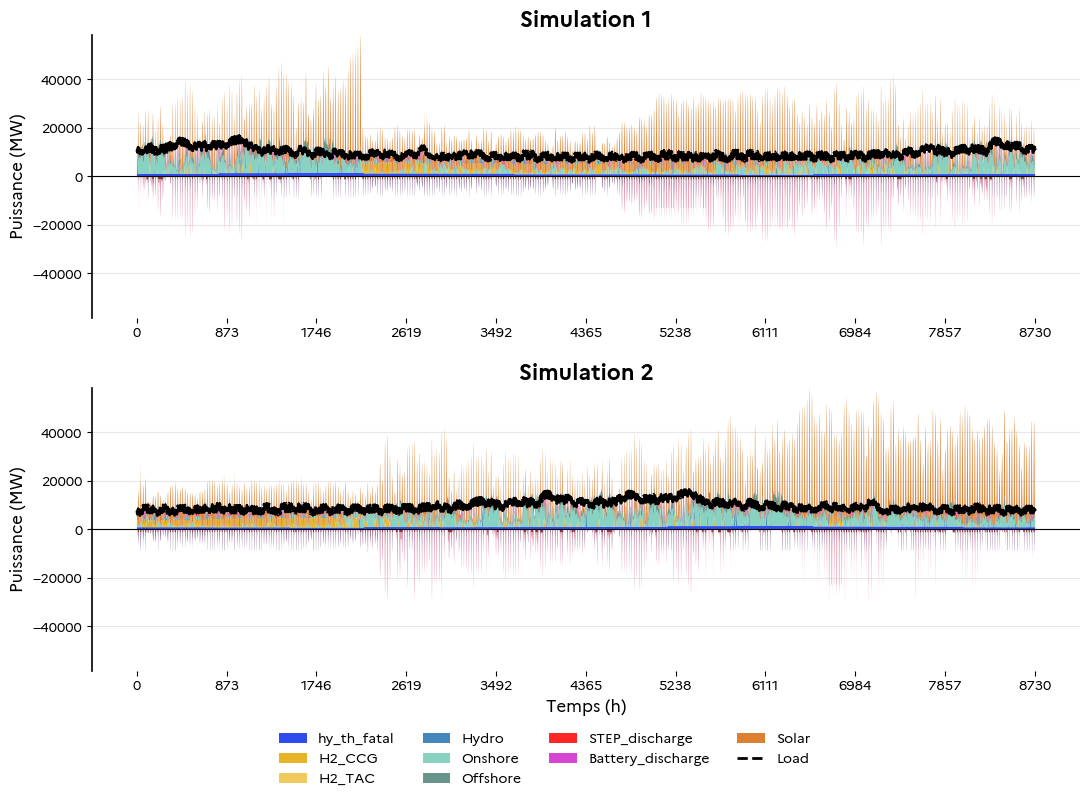

In [331]:
fig, axes = plt.subplots(
    nrows=2, ncols=1,
    figsize=(11,8),
    sharex=False,   # change en True si mêmes index
    sharey=True
)

# =====================================================
# GRAPHE 1  
# =====================================================
ax = axes[0]

ax.stackplot(
    df_global1.index,
    [df_global1[c] for c in prod_cols],
    colors=[palette[c] for c in prod_cols],
    labels=prod_cols,
    alpha=0.85
)

ax.stackplot(
    df_global1.index,
    [-df_global1[c] for c in charge_cols],
    colors=[palette[c] for c in charge_cols],
    alpha=0.85
)

ax.axhline(0, color="black", linewidth=0.8)

ax.plot(
    df_global1.index,
    df_global1['Load'],
    color="black",
    linestyle='--',
    linewidth=2,
    label="Load"
)

ax.set_title("Simulation 1")
ax.set_ylabel("Puissance (MW)")

# ----- STYLE -----
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)

# =====================================================
# GRAPHE 2  
# =====================================================
ax = axes[1]

ax.stackplot(
    df_global2.index,
    [df_global2[c] for c in prod_cols],
    colors=[palette[c] for c in prod_cols],
    alpha=0.85
)

ax.stackplot(
    df_global2.index,
    [-df_global2[c] for c in charge_cols],
    colors=[palette[c] for c in charge_cols],
    alpha=0.85
)

ax.axhline(0, color="black", linewidth=0.8)

ax.plot(
    df_global2.index,
    df_global2['Load'],
    color="black",
    linestyle='--',
    linewidth=2
)

ax.set_title("Simulation 2")
ax.set_xlabel("Temps (h)")
ax.set_ylabel("Puissance (MW)")

# ----- STYLE -----
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)

# Limites communes en y
ymax = max(
    df_global1[prod_cols].sum(axis=1).max(),
    df_global2[prod_cols].sum(axis=1).max(),
    df_global1[charge_cols].sum(axis=1).max(),
    df_global2[charge_cols].sum(axis=1).max()
)

for ax in axes:
    ax.set_ylim(-ymax, ymax)

# ----- TICKS ABSCISSES -----
for ax, dfg in zip(axes, [df_global1, df_global2]):
    ax.set_xticks(range(0, len(dfg.index), max(1, len(dfg.index)//10)))
    ax.set_xticklabels([str(i) for i in range(0, len(dfg.index), max(1, len(dfg.index)//10))])

# ----- LÉGENDE COMMUNE -----
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=False
)

# Ajustements finaux
plt.tight_layout(rect=[0, 0.08, 1, 1])  # bottom=0.08 pour légende
plt.subplots_adjust(hspace=0.25)       # espace entre graphes

plt.show()

### **1.2 Semaines sous tension**

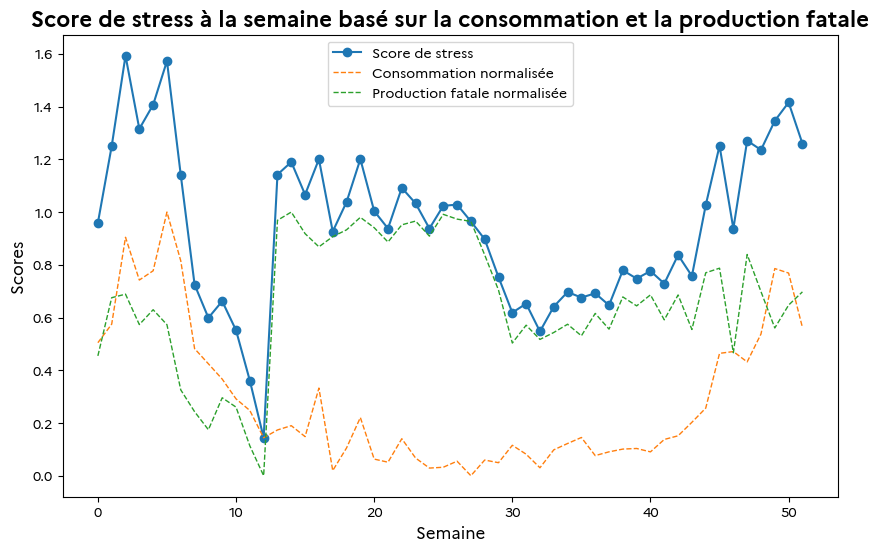

Top 5 semaines les plus stressantes :
week
2     1.592869
5     1.572722
50    1.415709
4     1.406812
49    1.346016
dtype: float64


In [332]:
df_global1['week'] = (df_global1.index // 24) // 7  # semaines 0 à 51
weekly_load = df_global1.groupby('week')['Load'].sum()  # ou sum() si tu préfères la conso totale

weekly_fatal = df_global1.groupby('week')[['Solar','Onshore','Offshore', 'hy_th_fatal']].sum().sum(axis=1)
# axis=1 pour sommer les types d'EnR par semaine

# Normalisation
load_norm = (weekly_load - weekly_load.min()) / (weekly_load.max() - weekly_load.min())
weekly_fatal_norm = 1 - ((weekly_fatal - weekly_fatal.min()) / (weekly_fatal.max() - weekly_fatal.min()))  # faible facteur = haute tension

stress_score = load_norm + weekly_fatal_norm

plt.figure(figsize=(10,6))
plt.plot(stress_score.index, stress_score.values, marker='o', label="Score de stress")
plt.plot(stress_score.index, load_norm.values, marker='', linestyle='--', linewidth=1, label="Consommation normalisée")
plt.plot(stress_score.index, weekly_fatal_norm.values, marker='', linestyle='--', linewidth=1, label="Production fatale normalisée")
plt.xlabel("Semaine")
plt.ylabel("Scores")
plt.title("Score de stress à la semaine basé sur la consommation et la production fatale")
plt.legend()
plt.show()


top5 = stress_score.sort_values(ascending=False).head(5)

print("Top 5 semaines les plus stressantes :")
print(top5)

# Semaine la plus et la moins stressante
week_max = stress_score.idxmax()
week_min = stress_score.idxmin()



**EOD de la semaine la plus tendue vs la moins tendue**

KeyError: 'hy_th_fatal'

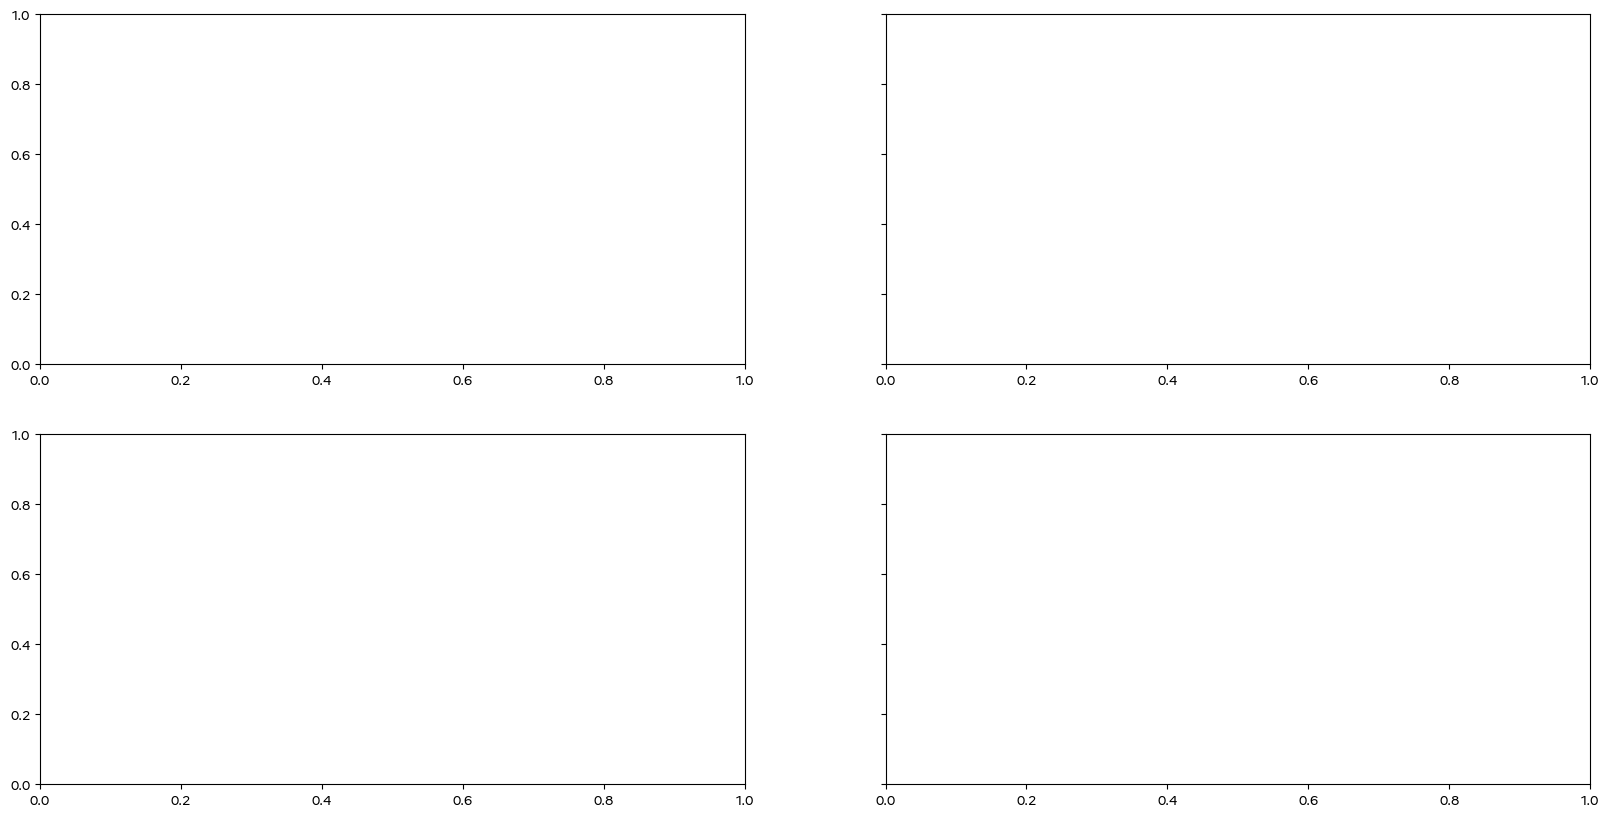

In [333]:

# ================================
# Préparer les DataFrames hebdomadaires
# ================================

# Ne pas reset l'index pour conserver les heures
df_max1 = df_global1.loc[week_max].copy()
df_min1 = df_global1.loc[week_min].copy()
df_max2 = df_global2.loc[week_max].copy()
df_min2 = df_global2.loc[week_min].copy()

# Créer un index horaire 0-167 pour la semaine (168h)
for df in [df_max1, df_min1, df_max2, df_min2]:
    df.index = range(len(df))

# ================================
# Création des subplots 2x2
# ================================
fig, axes = plt.subplots(2, 2, figsize=(20,10), sharey=True)

# --------- SIMU 1 ---------
for ax, df_week, title in zip(
    axes[0],
    [df_max1, df_min1],
    [f"Semaine la plus tendue ({week_max})",
     f"Semaine la moins tendue ({week_min})"]
):
    # Stack positif (production)
    ax.stackplot(
        df_week.index,
        [df_week[c] for c in prod_cols],
        colors=[palette[c] for c in prod_cols],
        alpha=0.85
    )

    # Stack négatif (charges)
    ax.stackplot(
        df_week.index,
        [-df_week[c] for c in charge_cols],
        colors=[palette[c] for c in charge_cols],
        alpha=0.85
    )

    # Ligne zéro
    ax.axhline(0, color="black", linewidth=0.8)

    # Load
    ax.plot(df_week.index, df_week['Load'],
            color="black", linestyle='--', linewidth=2, label="Load")

    ax.set_title(title)
    ax.set_xlabel("Heures")
    ax.grid(axis="y", alpha=0.3)

# --------- SIMU 2 ---------
for ax, df_week, title in zip(
    axes[1],
    [df_max2, df_min2],
    [f"Semaine la plus tendue ({week_max})",
     f"Semaine la moins tendue ({week_min})"]
):
    ax.stackplot(
        df_week.index,
        [df_week[c] for c in prod_cols],
        colors=[palette[c] for c in prod_cols],
        alpha=0.85
    )

    ax.stackplot(
        df_week.index,
        [-df_week[c] for c in charge_cols],
        colors=[palette[c] for c in charge_cols],
        alpha=0.85
    )

    ax.axhline(0, color="black", linewidth=0.8)
    ax.plot(df_week.index, df_week['Load'],
            color="black", linestyle='--', linewidth=2)

    ax.set_title(title)
    ax.set_xlabel("Heures")
    ax.grid(axis="y", alpha=0.3)

# --------- Labels Y seulement à gauche ---------
axes[0,0].set_ylabel("Puissance (MW)")
axes[1,0].set_ylabel("Puissance (MW)")

# --------- Titres globaux par simulation ---------
fig.text(0.25, 0.96, "SIMU 1", ha='center', fontsize=16, fontweight='bold')
fig.text(0.75, 0.96, "SIMU 2", ha='center', fontsize=16, fontweight='bold')

# --------- Légende commune ---------
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=False
)

# Ajustement pour laisser la place à la légende
plt.tight_layout(rect=[0, 0.05, 1, 0.94])

plt.show()

## **2. Capacités installées**

In [ ]:
import json

# ------------------------
# Paramètres des unités H2
# ------------------------
Pmax_CCG_unite = 430  # MW par unité CCG
Pmax_TAC_unite = 85   # MW par unité TAC


with open(f"results/{id1}/parc_annuel.json", "r") as f:
    parc_annuel1 = json.load(f)

with open(f"results/{id2}/parc_annuel.json", "r") as f:
    parc_annuel2 = json.load(f)

# ------------------------
# Fonction pour créer les variables dynamiquement
# ------------------------
def creer_variables(parc_annuel, prefix=""):
    vars_dict = {}
    
    # Capacités classiques
    for techno, val in parc_annuel["capacites_MW"].items():
        var_name = f"{prefix}{techno}_capacity"
        vars_dict[var_name] = val
    
    # H2 CCG et TAC en MW
    if "H2" in parc_annuel:
        nb_CCG = parc_annuel["H2"]["CCG"]["nombre_installees"]
        nb_TAC = parc_annuel["H2"]["TAC"]["nombre_installees"]
        
        vars_dict[f"{prefix}H2_CCG_capacity"] = nb_CCG * Pmax_CCG_unite
        vars_dict[f"{prefix}H2_TAC_capacity"] = nb_TAC * Pmax_TAC_unite
    
    return vars_dict

# ------------------------
# Création des variables pour les deux simulations
# ------------------------
vars1 = creer_variables(parc_annuel1, prefix="sim1_")
vars2 = creer_variables(parc_annuel2, prefix="sim2_")

# ------------------------
# Injection dans l'espace de noms global
# ------------------------
globals().update(vars1)
globals().update(vars2)

# ------------------------
# Vérification
# ------------------------
print("Simulation 1:")
for k, v in vars1.items():
    print(f"{k} = {v}")

print("\nSimulation 2:")
for k, v in vars2.items():
    print(f"{k} = {v}")


Simulation 1:
sim1_electrolyzer_capacity = 21403.0
sim1_offshore_capacity = 5000.0
sim1_onshore_capacity = 15000.0
sim1_solar_capacity = 50000.0
sim1_battery_capacity = 7500.0
sim1_H2_CCG_capacity = 4300
sim1_H2_TAC_capacity = 850

Simulation 2:
sim2_electrolyzer_capacity = 21403.0
sim2_offshore_capacity = 5000.0
sim2_onshore_capacity = 15000.0
sim2_solar_capacity = 50000.0
sim2_battery_capacity = 7500.0
sim2_H2_CCG_capacity = 4300
sim2_H2_TAC_capacity = 850
4300


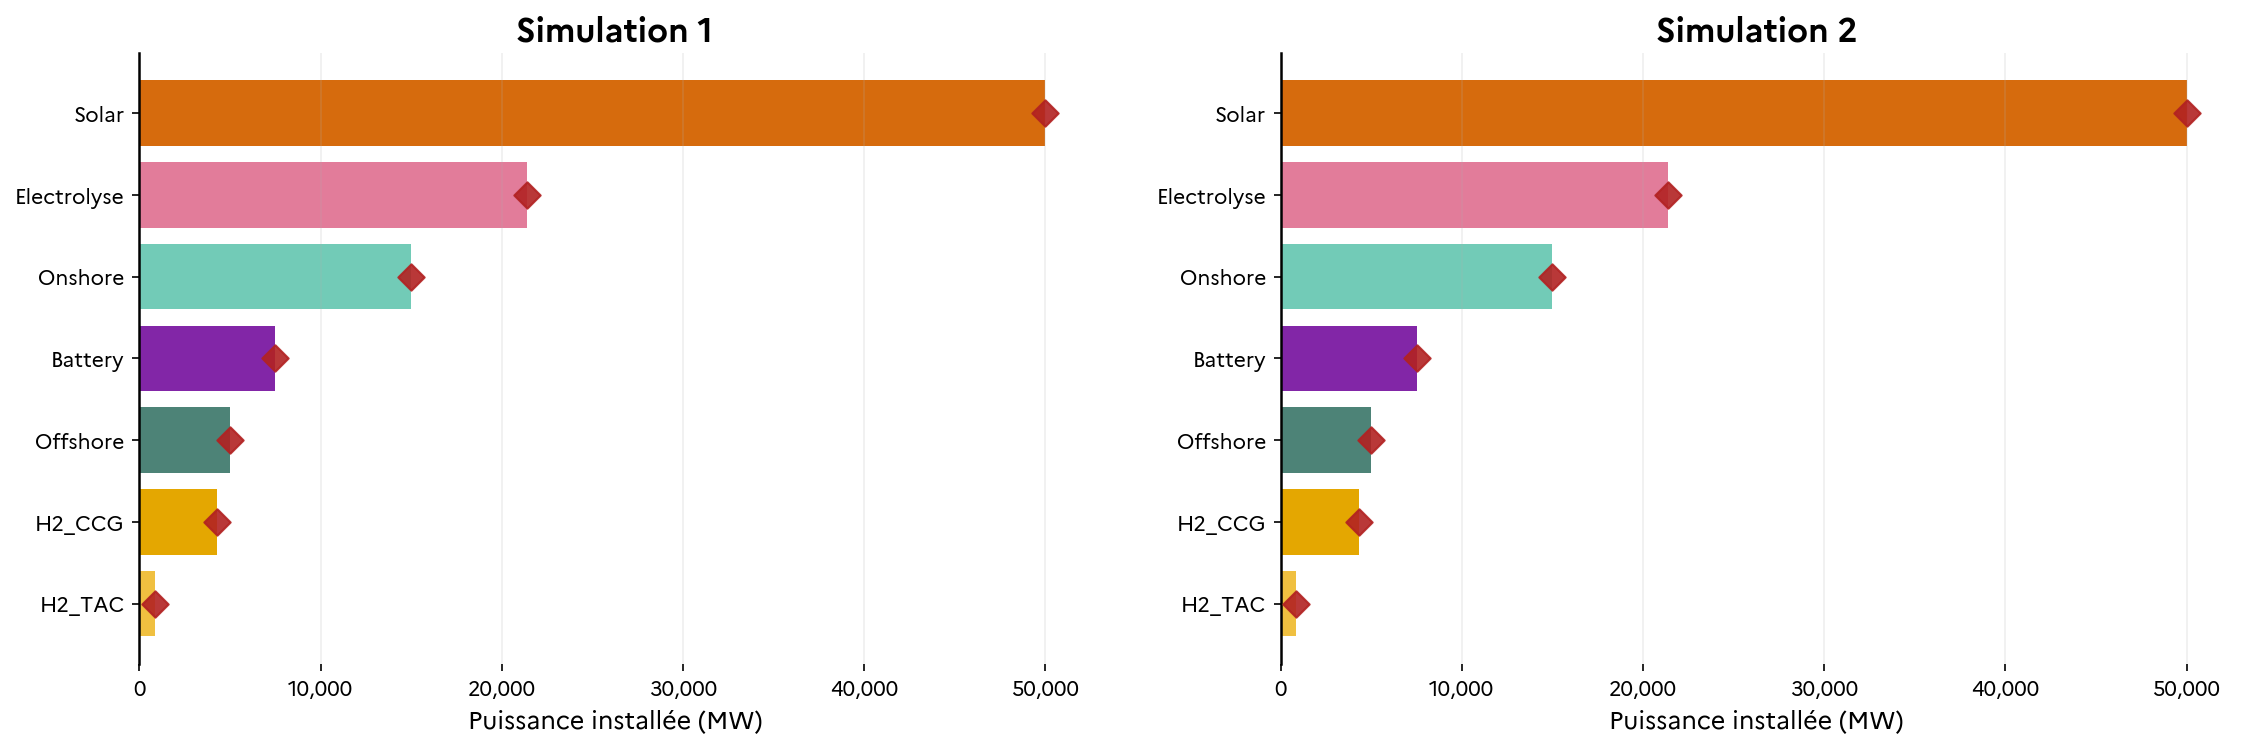

In [ ]:

import matplotlib.ticker as mtick
from matplotlib.offsetbox import OffsetImage, AnnotationBbox


# --- Fonctions utilitaires ---
def add_icon(ax, x, y, icon_path, zoom=0.08):
    if not os.path.exists(icon_path):
        return
    img = plt.imread(icon_path)
    ab = AnnotationBbox(
        OffsetImage(img, zoom=zoom),
        (x, y),
        frameon=False,
        box_alignment=(0, 0.5)
    )
    ax.add_artist(ab)

def add_gisement_marker(ax, y, value, size=80):
    ax.scatter(value, y, marker='D', color="#B22222", s=size, zorder=5, alpha=0.9, label="Gisement" if y == 0 else "")

# --- Plot Sim1 et Sim2 ---
fig = plt.figure(figsize=(18,18), dpi=150)

# Sim1
ax1 = plt.subplot2grid((3,2), (0,0))
labels, values = zip(*sorted(sim1_data.items(), key=lambda t: t[1]))
bars = ax1.barh(labels, values, color=[palette[l] for l in labels])
ax1.set_title("Simulation 1")
ax1.set_xlabel("Puissance installée (MW)")
ax1.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax1.grid(axis="x", alpha=0.2)
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.spines["left"].set_visible(True)
ax1.spines["left"].set_linewidth(1.2)

xmin, xmax = ax1.get_xlim()
icon_x = xmin + (xmax - xmin) * 0.02
for y, label in enumerate(labels):
    add_icon(ax1, icon_x, y, icons.get(label, ""), zoom=0.07)
    add_gisement_marker(ax1, y, sim1_data[label])

# Sim2
ax2 = plt.subplot2grid((3,2), (0,1))
labels, values = zip(*sorted(sim2_data.items(), key=lambda t: t[1]))
bars = ax2.barh(labels, values, color=[palette[l] for l in labels])
ax2.set_title("Simulation 2")
ax2.set_xlabel("Puissance installée (MW)")
ax2.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax2.grid(axis="x", alpha=0.2)
for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.spines["left"].set_visible(True)
ax2.spines["left"].set_linewidth(1.2)

xmin, xmax = ax2.get_xlim()
icon_x = xmin + (xmax - xmin) * 0.02
for y, label in enumerate(labels):
    add_icon(ax2, icon_x, y, icons.get(label, ""), zoom=0.07)
    add_gisement_marker(ax2, y, sim2_data[label])

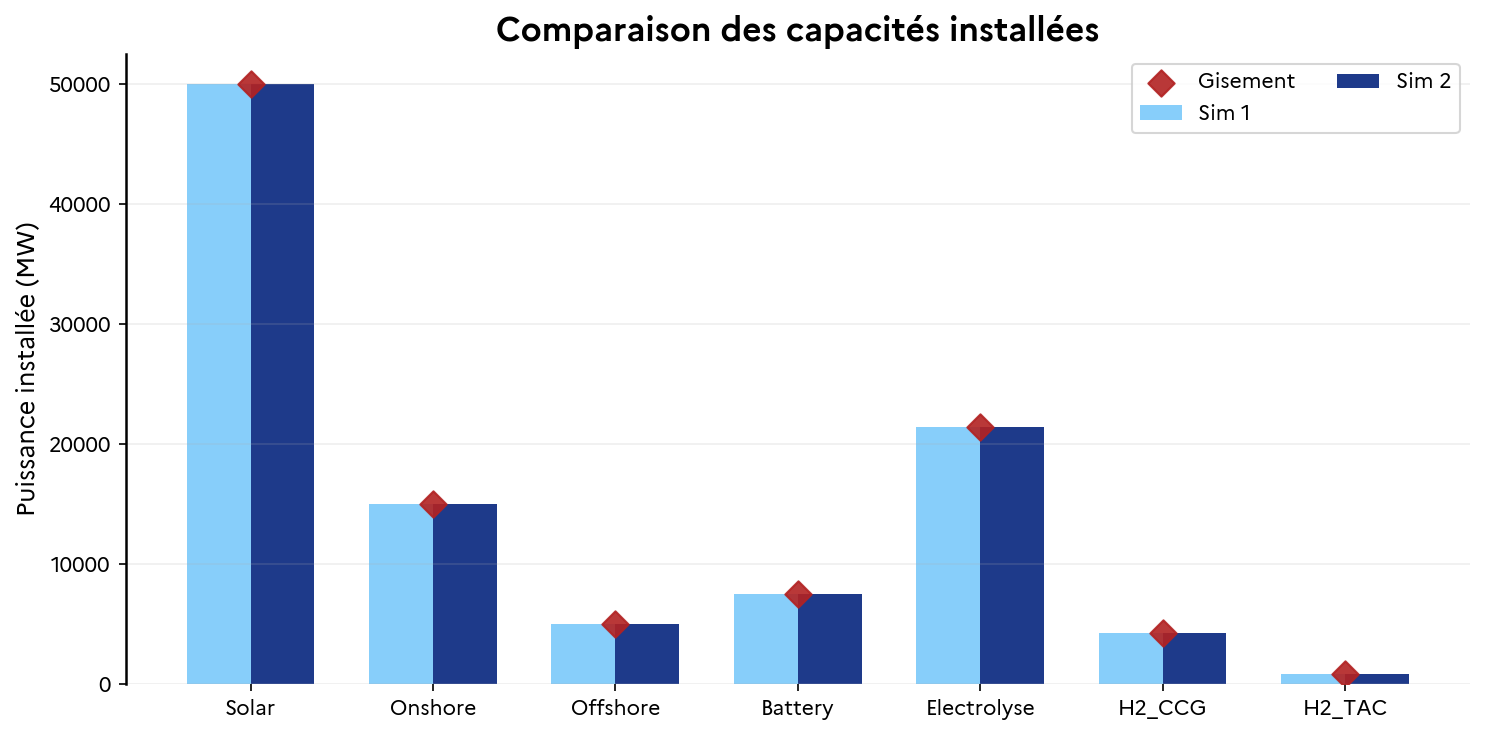

In [ ]:
import matplotlib.pyplot as plt

width = 0.35
x = range(len(sim1_data))
labels = list(sim1_data.keys())
color_sim1 = "#87CEFA"  # bleu clair
color_sim2 = "#1E3A8A"  # bleu foncé

fig, ax = plt.subplots(figsize=(10,5), dpi=150)

# Barres Sim1 et Sim2
ax.bar([i - width/2 for i in x], [sim1_data[l] for l in labels],
       width=width, color=color_sim1, label="Sim 1")
ax.bar([i + width/2 for i in x], [sim2_data[l] for l in labels],
       width=width, color=color_sim2, label="Sim 2")

# Losange au centre de chaque paire (gisement)
for i, l in enumerate(labels):
    center = (sim1_data[l] + sim2_data[l])/2
    ax.scatter(i, center, marker='D', color="#B22222", s=80, zorder=5, alpha=0.9, label="Gisement" if i == 0 else "")

# Labels, titre et légende
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Puissance installée (MW)")
ax.set_title("Comparaison des capacités installées")
ax.legend(ncol=2)
ax.grid(axis="y", alpha=0.2)

# Style minimaliste : enlever cadre sauf trait gauche
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["left"].set_linewidth(1.2)

plt.tight_layout()
plt.show()

## **3. Capacités de stockage**

### **Batteries et STEP SIMU 1**

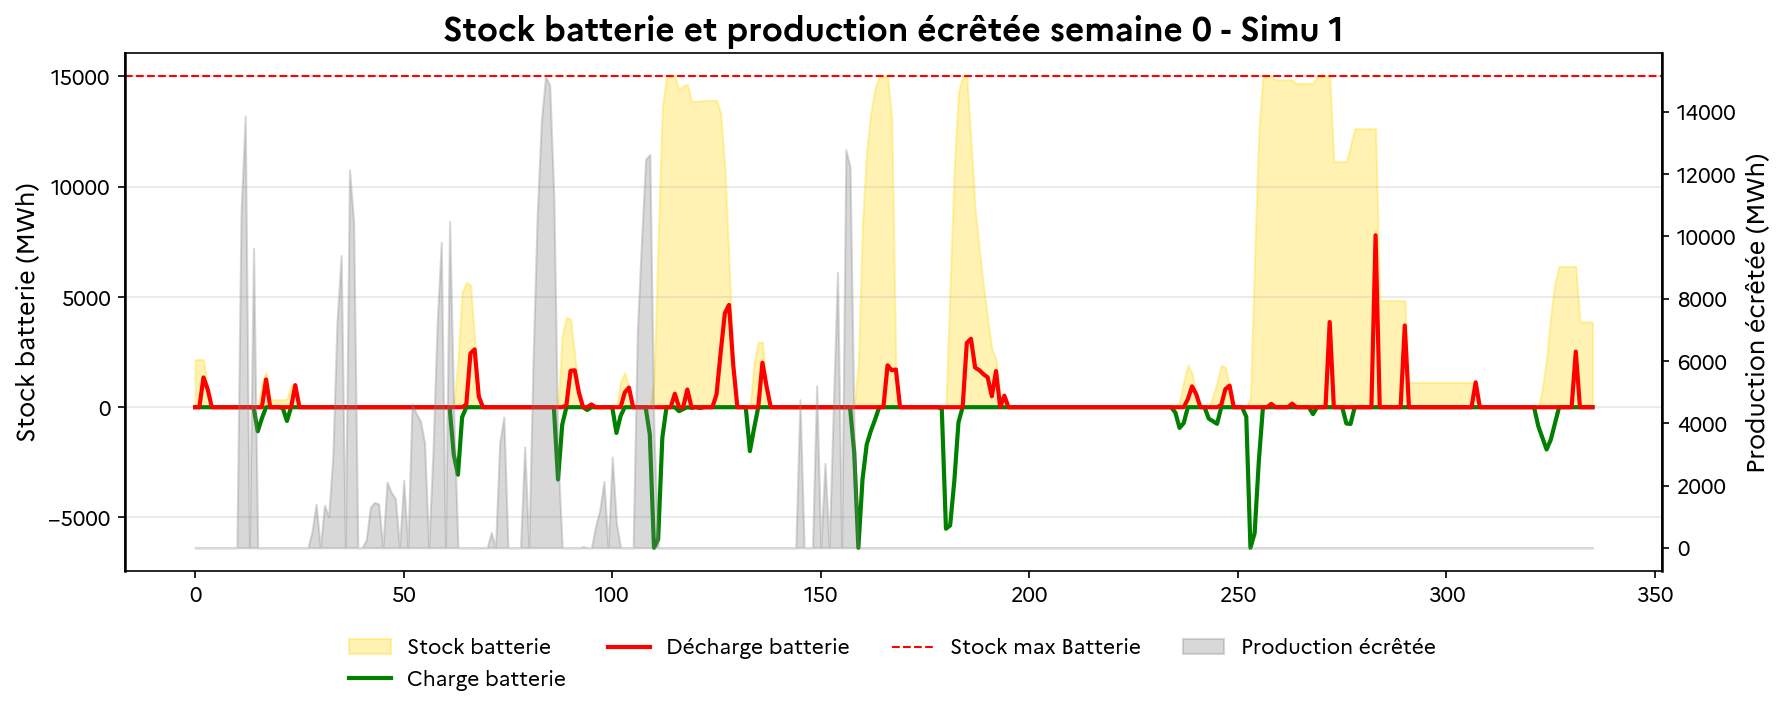

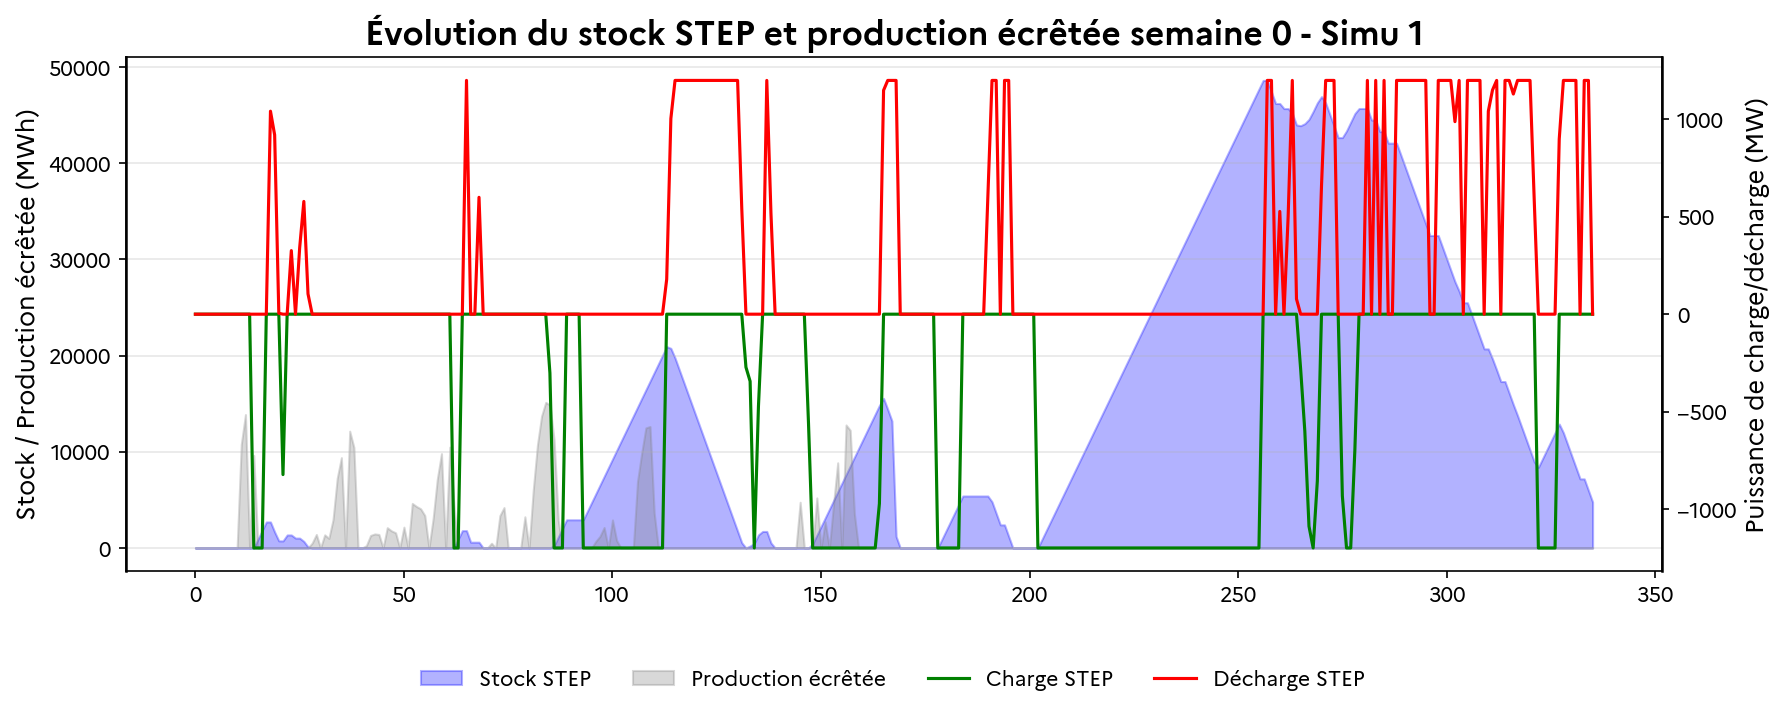

In [ ]:
# -----------------------------
# Paramètres batterie
# -----------------------------
CapaBattery1 = sim1_battery_capacity
d_battery = 2   # heures
stock_max_battery = CapaBattery1 * d_battery
rbattery = 0.85

time = df1.index

# -----------------------------
# Plot Stock Batterie + Production écrêtée
# -----------------------------
fig, ax1 = plt.subplots(figsize=(12,5), dpi=150)

# Stock batterie et courbes charge/décharge
ax1.fill_between(time, 0, df1["Battery_stock"], color='gold', alpha=0.3, label="Stock batterie")
ax1.plot(time, -df1["Battery_charge"]*rbattery, linewidth=2, color='green', label="Charge batterie")
ax1.plot(time, df1["Battery_discharge"]/rbattery, linewidth=2, color='red', label="Décharge batterie")
ax1.axhline(y=stock_max_battery, linestyle="--", linewidth=1, color="red", label="Stock max Batterie")

ax1.set_ylabel("Stock batterie (MWh)")
ax1.grid(axis="y", alpha=0.3)

# -----------------------------
# Style minimaliste
# -----------------------------
ax1.set_facecolor("white")
for spine in ax1.spines.values():
    spine.set_visible(False)        # supprime tous les cadres
ax1.spines["left"].set_visible(True)
ax1.spines["left"].set_linewidth(1.2)
ax1.spines["right"].set_visible(True)
ax1.spines["right"].set_linewidth(1.2)

# Axe secondaire : production écrêtée
ax2 = ax1.twinx()
ax2.fill_between(time, 0, df1["Exces"], color='gray', alpha=0.3, label="Production écrêtée")
ax2.set_ylabel("Production écrêtée (MWh)")
ax2.grid(False)
ax2.set_facecolor("none")  # fond transparent

# Légende combinée en bas
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
fig.legend(lines_1 + lines_2, labels_1 + labels_2,
           loc="lower center", ncol=4, frameon=False)

plt.title(f"Stock batterie et production écrêtée semaine {WEEK_TARGET} - {name_simu_1}")
plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()


# -----------------------------
# Plot Stock STEP + Production écrêtée
# -----------------------------
fig, ax1 = plt.subplots(figsize=(12,5), dpi=150)

# Stock STEP et production écrêtée
ax1.fill_between(time, 0, df1["STEP_stock"], color='blue', alpha=0.3, label="Stock STEP")
ax1.fill_between(time, 0, df1["Exces"], color='gray', alpha=0.3, label="Production écrêtée")
ax1.set_ylabel("Stock / Production écrêtée (MWh)")
ax1.grid(axis="y", alpha=0.3)

# Style minimaliste
ax1.set_facecolor("white")
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.spines["left"].set_visible(True)
ax1.spines["left"].set_linewidth(1.2)
ax1.spines["right"].set_visible(True)
ax1.spines["right"].set_linewidth(1.2)

# Axe secondaire : charge/décharge STEP
ax2 = ax1.twinx()
ax2.plot(time, -df1["STEP_charge"], color='green', linewidth=1.5, label="Charge STEP")
ax2.plot(time, df1["STEP_discharge"], color='red', linewidth=1.5, label="Décharge STEP")
ax2.set_ylabel("Puissance de charge/décharge (MW)")
ax2.grid(False)
ax2.set_facecolor("none")

# Légende combinée en bas
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
fig.legend(lines_1 + lines_2, labels_1 + labels_2,
           loc="lower center", ncol=4, frameon=False)

plt.title(f"Évolution du stock STEP et production écrêtée semaine {WEEK_TARGET} - {name_simu_1}")
plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

**Test : charge et décharge simultanée**

In [ ]:
#Batteries

# Test si charge et décharge sont simultanées
simultaneous = np.logical_and(df_global1["Battery_charge"] > 0, df_global1["Battery_discharge"] > 0)

if simultaneous.any():
    print("⚠️ Attention : charge et décharge simultanées détectées !")
    # Afficher les indices où cela se produit
    print("Heures concernées :", np.where(simultaneous)[0])
else:
    print("✅ Pas de charge/décharge simultanée détectée")

✅ Pas de charge/décharge simultanée détectée


In [ ]:
#STEP

# Test si charge et décharge sont simultanées
simultaneous = np.logical_and(df_global1["STEP_charge"] > 0, df_global1["STEP_discharge"] > 0)

if simultaneous.any():
    print("⚠️ Attention : charge et décharge simultanées détectées !")
    # Afficher les indices où cela se produit
    print("Heures concernées :", np.where(simultaneous)[0])
else:
    print("✅ Pas de charge/décharge simultanée détectée")

✅ Pas de charge/décharge simultanée détectée


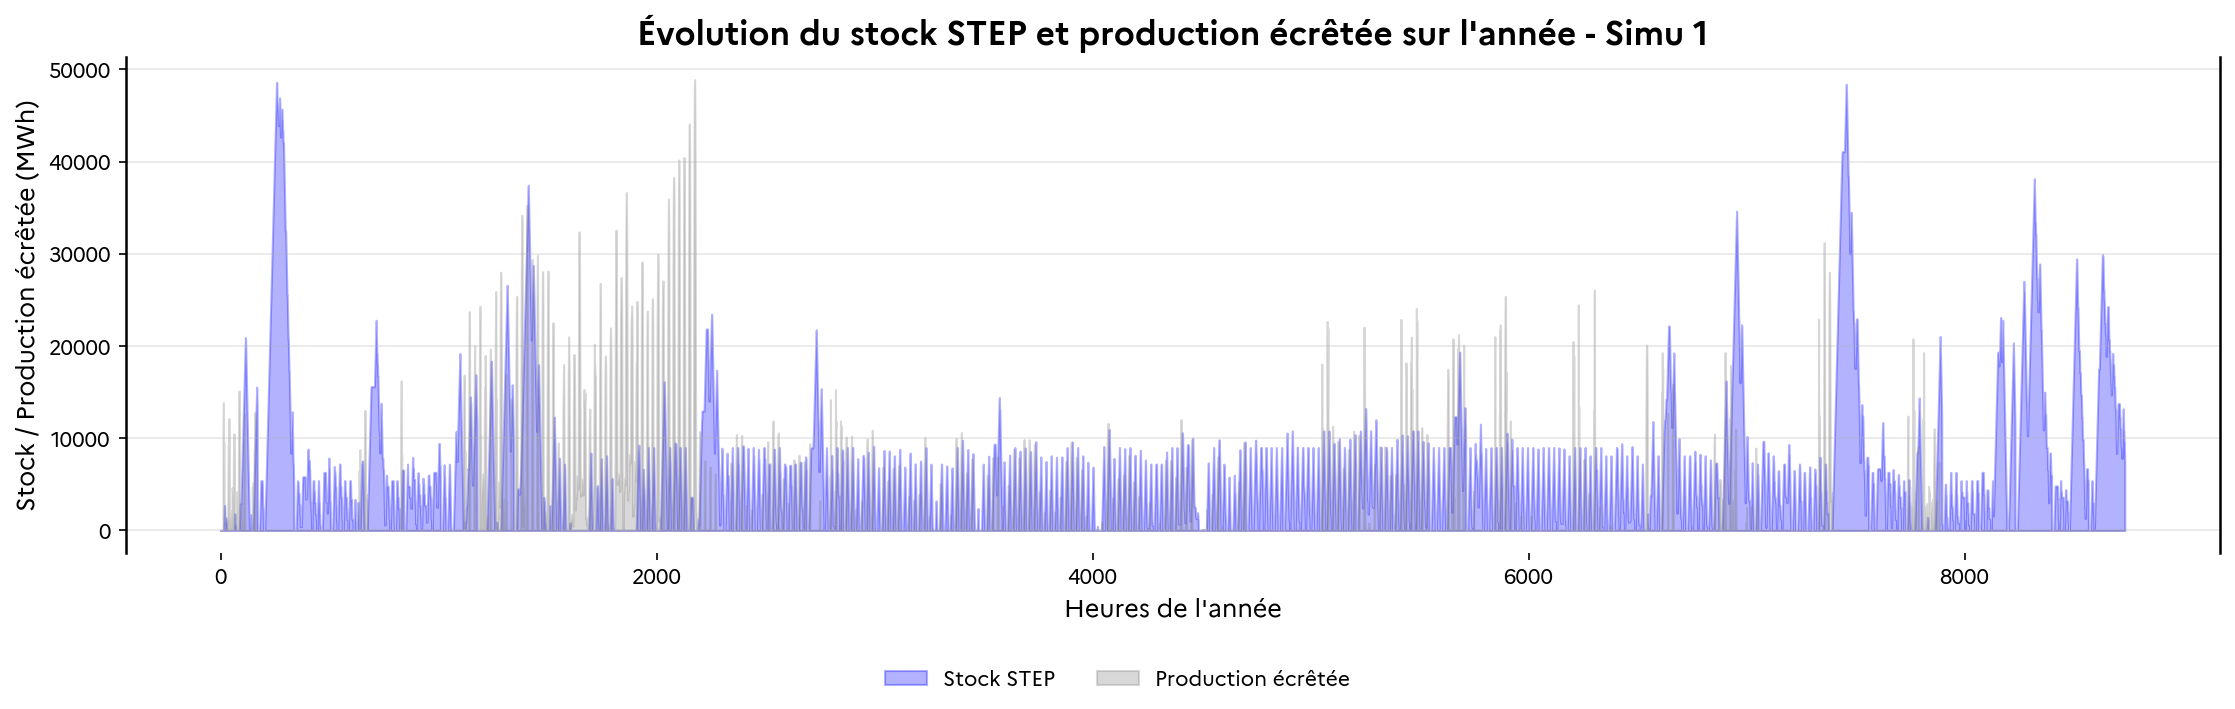

In [ ]:
import matplotlib.pyplot as plt

time = df_global1.index  # index de 0 à 8735

fig, ax1 = plt.subplots(figsize=(15,5), dpi=150)

# -----------------------------
# Axe principal : Stock STEP et Production écrêtée (Exces)
# -----------------------------
ax1.fill_between(time, 0, df_global1["STEP_stock"], color='blue', alpha=0.3, label="Stock STEP")
ax1.fill_between(time, 0, df_global1["Exces"], color='gray', alpha=0.3, label="Production écrêtée")
ax1.set_xlabel("Heures de l'année")
ax1.set_ylabel("Stock / Production écrêtée (MWh)")

# -----------------------------
# Style minimaliste
# -----------------------------
ax1.grid(axis="y", alpha=0.3)
ax1.set_facecolor("white")
for spine in ax1.spines.values():
    spine.set_visible(False)  # supprime tous les cadres
ax1.spines["left"].set_visible(True)
ax1.spines["left"].set_linewidth(1.2)
ax1.spines["right"].set_visible(True)
ax1.spines["right"].set_linewidth(1.2)

# -----------------------------
# Légende centrée en bas
# -----------------------------
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)

plt.title(f"Évolution du stock STEP et production écrêtée sur l'année - {name_simu_1}")
plt.tight_layout(rect=[0, 0.08, 1, 0.95])  # laisse de la place pour la légende en bas
plt.show()


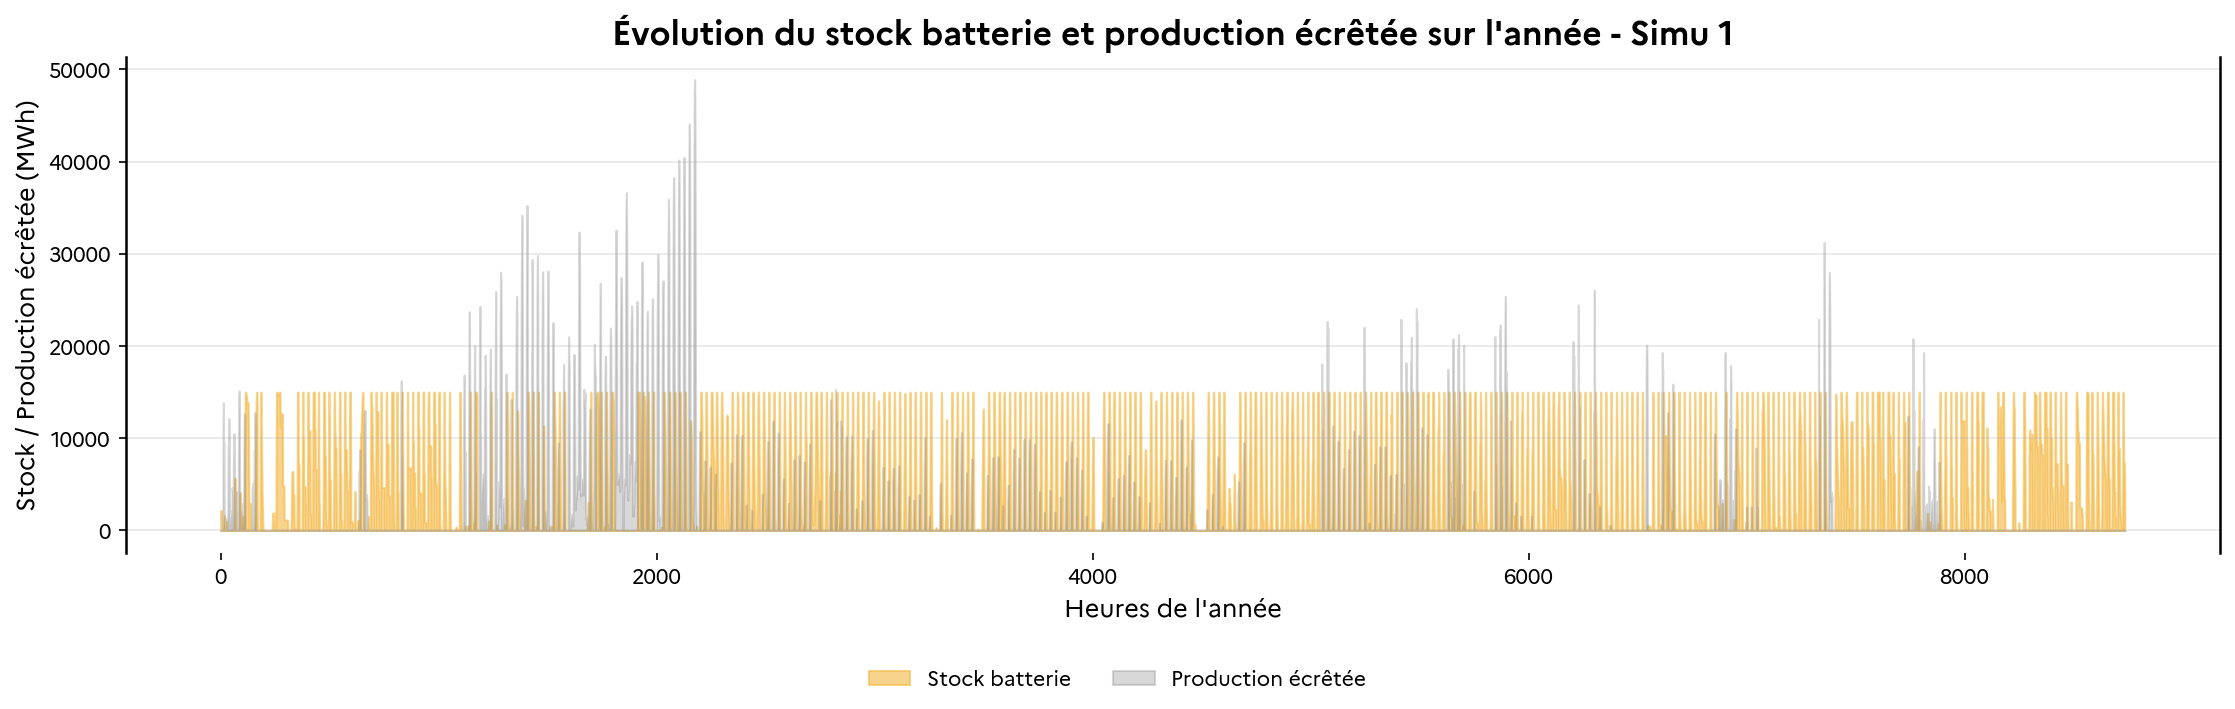

In [ ]:
import matplotlib.pyplot as plt

time = df_global1.index  # index de 0 à 8735

fig, ax1 = plt.subplots(figsize=(15,5), dpi=150)

# -----------------------------
# Axe principal : Stock batterie + Production écrêtée
# -----------------------------
ax1.fill_between(time, 0, df_global1["Battery_stock"], color='#f4b740', alpha=0.6, label="Stock batterie")
ax1.fill_between(time, 0, df_global1["Exces"], color='gray', alpha=0.3, label="Production écrêtée")
ax1.set_xlabel("Heures de l'année")
ax1.set_ylabel("Stock / Production écrêtée (MWh)")

# -----------------------------
# Style minimaliste
# -----------------------------
ax1.grid(axis="y", alpha=0.3)
ax1.set_facecolor("white")
for spine in ax1.spines.values():
    spine.set_visible(False)  # supprime tous les cadres
ax1.spines["left"].set_visible(True)
ax1.spines["left"].set_linewidth(1.2)
ax1.spines["right"].set_visible(True)
ax1.spines["right"].set_linewidth(1.2)

# -----------------------------
# Légende centrée en bas
# -----------------------------
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)

plt.title(f"Évolution du stock batterie et production écrêtée sur l'année - {name_simu_1}")
plt.tight_layout(rect=[0, 0.08, 1, 0.95])  # laisse de la place pour la légende
plt.show()

### **Batteries et STEP SIMU 2**

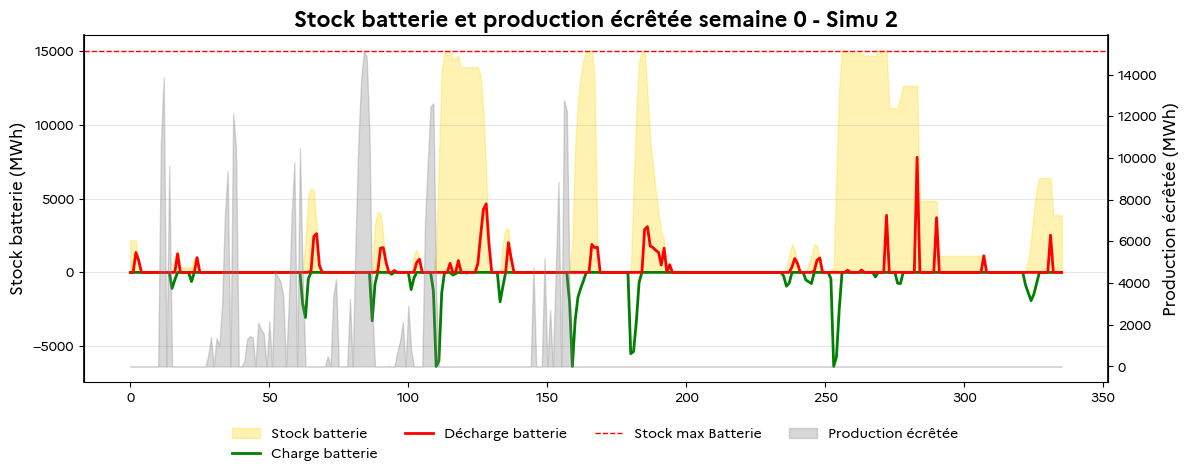

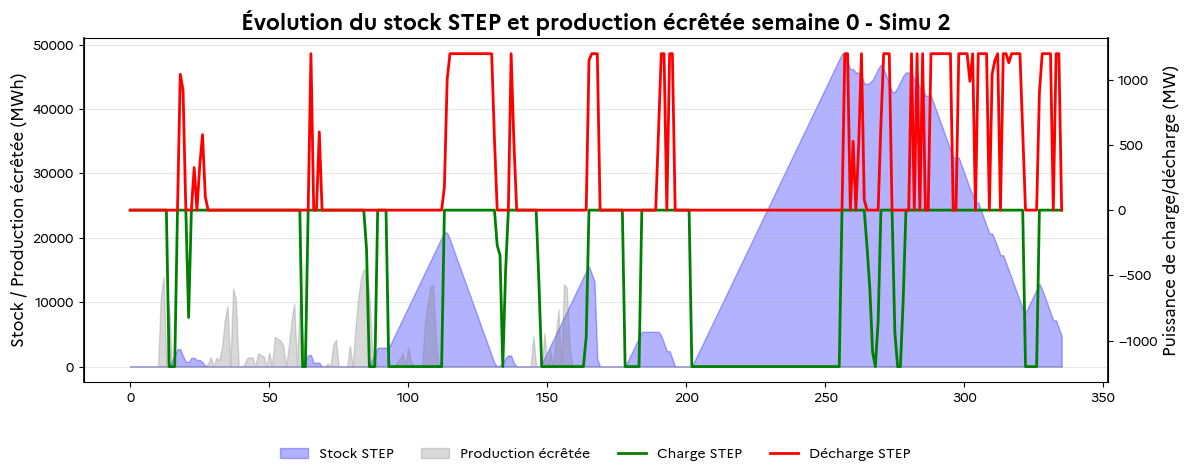

In [ ]:
# -----------------------------
# Paramètres batterie
# -----------------------------
CapaBattery1 = sim2_battery_capacity
d_battery = 2   # heures
stock_max_battery = CapaBattery1 * d_battery
rbattery = 0.85

time = df2.index

# -----------------------------
# Plot Stock Batterie + Production écrêtée
# -----------------------------
fig, ax1 = plt.subplots(figsize=(12,5))

# Stock batterie et courbes charge/décharge
ax1.fill_between(time, 0, df2["Battery_stock"], color='gold', alpha=0.3, label="Stock batterie")
ax1.plot(time, -df2["Battery_charge"]*rbattery, linewidth=2, color='green', label="Charge batterie")
ax1.plot(time, df2["Battery_discharge"]/rbattery, linewidth=2, color='red', label="Décharge batterie")
ax1.axhline(y=stock_max_battery, linestyle="--", linewidth=1, color="red", label="Stock max Batterie")

ax1.set_ylabel("Stock batterie (MWh)")
ax1.grid(axis="y", alpha=0.3)

# -----------------------------
# Style minimaliste
# -----------------------------
ax1.set_facecolor("white")
for spine in ax1.spines.values():
    spine.set_visible(False)        # supprime tous les cadres
ax1.spines["left"].set_visible(True)
ax1.spines["left"].set_linewidth(1.2)
ax1.spines["right"].set_visible(True)
ax1.spines["right"].set_linewidth(1.2)

# Axe secondaire : production écrêtée
ax2 = ax1.twinx()
ax2.fill_between(time, 0, df2["Exces"], color='gray', alpha=0.3, label="Production écrêtée")
ax2.set_ylabel("Production écrêtée (MWh)")
ax2.grid(False)
ax2.set_facecolor("none")  # fond transparent

# Légende combinée en bas
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
fig.legend(lines_1 + lines_2, labels_1 + labels_2,
           loc="lower center", ncol=4, frameon=False)

plt.title(f"Stock batterie et production écrêtée semaine {WEEK_TARGET} - {name_simu_2}")
plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()


# -----------------------------
# Plot Stock STEP + Production écrêtée
# -----------------------------
fig, ax1 = plt.subplots(figsize=(12,5))

# Stock STEP et production écrêtée
ax1.fill_between(time, 0, df2["STEP_stock"], color='blue', alpha=0.3, label="Stock STEP")
ax1.fill_between(time, 0, df2["Exces"], color='gray', alpha=0.3, label="Production écrêtée")
ax1.set_ylabel("Stock / Production écrêtée (MWh)")
ax1.grid(axis="y", alpha=0.3)

# Style minimaliste
ax1.set_facecolor("white")
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.spines["left"].set_visible(True)
ax1.spines["left"].set_linewidth(1.2)
ax1.spines["right"].set_visible(True)
ax1.spines["right"].set_linewidth(1.2)

# Axe secondaire : charge/décharge STEP
ax2 = ax1.twinx()
ax2.plot(time, -df2["STEP_charge"], color='green', linewidth=2, label="Charge STEP")
ax2.plot(time, df2["STEP_discharge"], color='red', linewidth=2, label="Décharge STEP")
ax2.set_ylabel("Puissance de charge/décharge (MW)")
ax2.grid(False)
ax2.set_facecolor("none")

# Légende combinée en bas
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
fig.legend(lines_1 + lines_2, labels_1 + labels_2,
           loc="lower center", ncol=4, frameon=False)

plt.title(f"Évolution du stock STEP et production écrêtée semaine {WEEK_TARGET} - {name_simu_2}")
plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

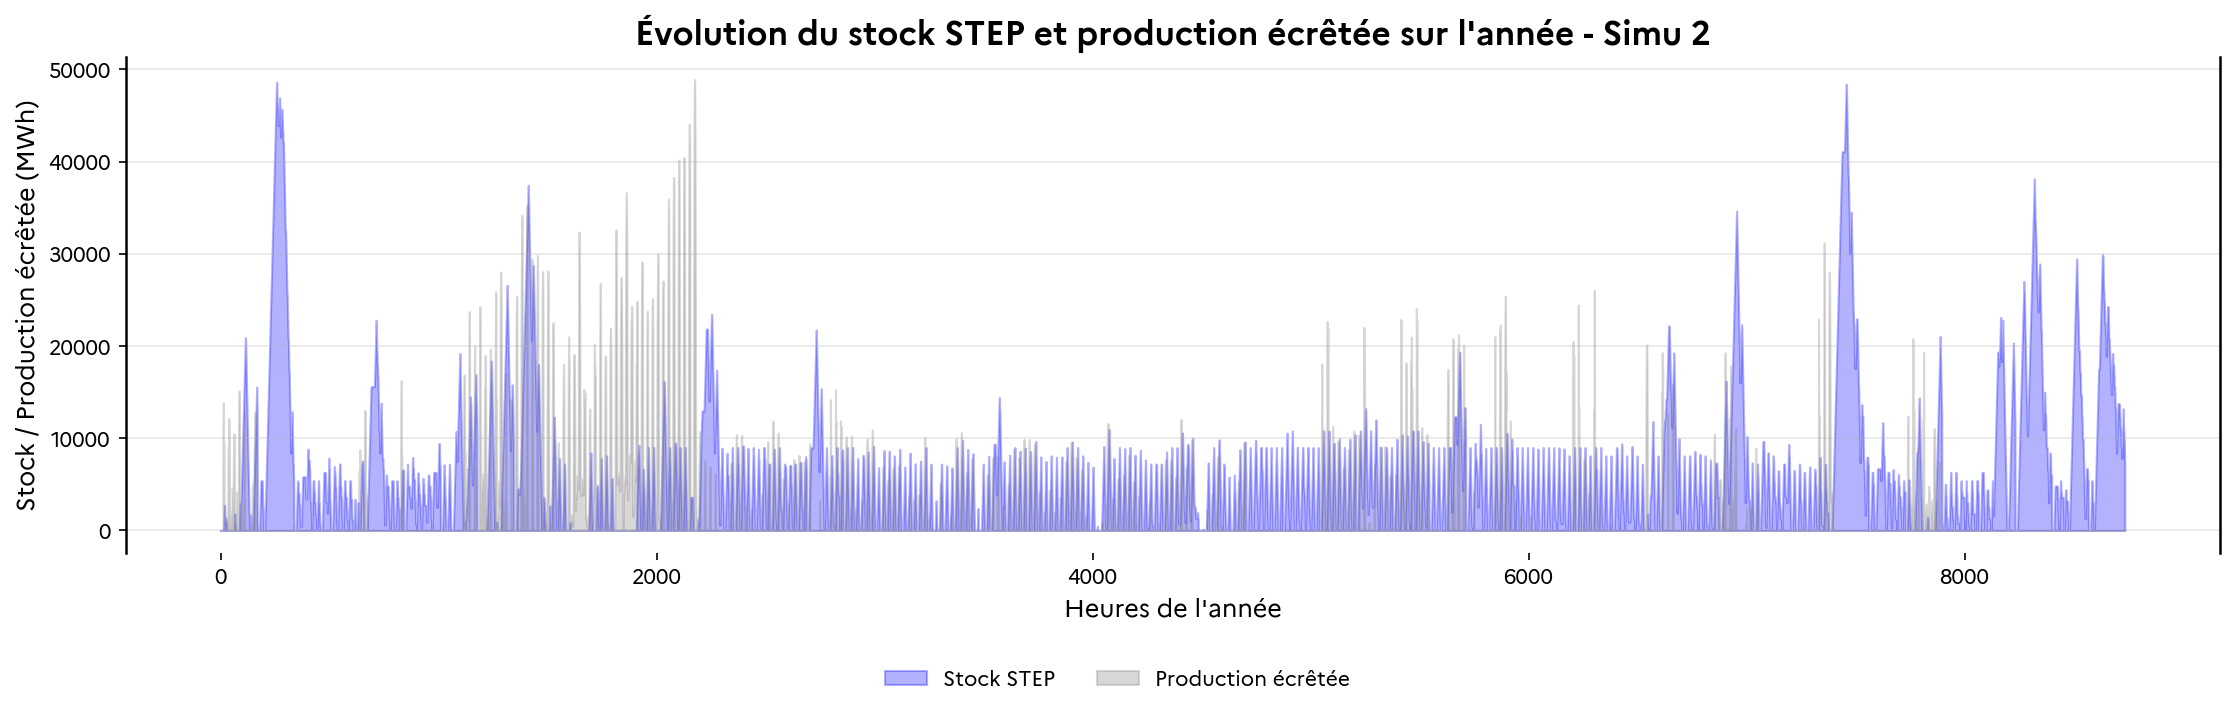

In [ ]:
import matplotlib.pyplot as plt

time = df_global2.index  # index de 0 à 8735

fig, ax1 = plt.subplots(figsize=(15,5), dpi=150)

# -----------------------------
# Axe principal : Stock STEP et Production écrêtée (Exces)
# -----------------------------
ax1.fill_between(time, 0, df_global2["STEP_stock"], color='blue', alpha=0.3, label="Stock STEP")
ax1.fill_between(time, 0, df_global2["Exces"], color='gray', alpha=0.3, label="Production écrêtée")
ax1.set_xlabel("Heures de l'année")
ax1.set_ylabel("Stock / Production écrêtée (MWh)")

# -----------------------------
# Style minimaliste
# -----------------------------
ax1.grid(axis="y", alpha=0.3)
ax1.set_facecolor("white")
for spine in ax1.spines.values():
    spine.set_visible(False)  # supprime tous les cadres
ax1.spines["left"].set_visible(True)
ax1.spines["left"].set_linewidth(1.2)
ax1.spines["right"].set_visible(True)
ax1.spines["right"].set_linewidth(1.2)

# -----------------------------
# Légende centrée en bas
# -----------------------------
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)

plt.title(f"Évolution du stock STEP et production écrêtée sur l'année - {name_simu_2}")
plt.tight_layout(rect=[0, 0.08, 1, 0.95])  # laisse de la place pour la légende en bas
plt.show()


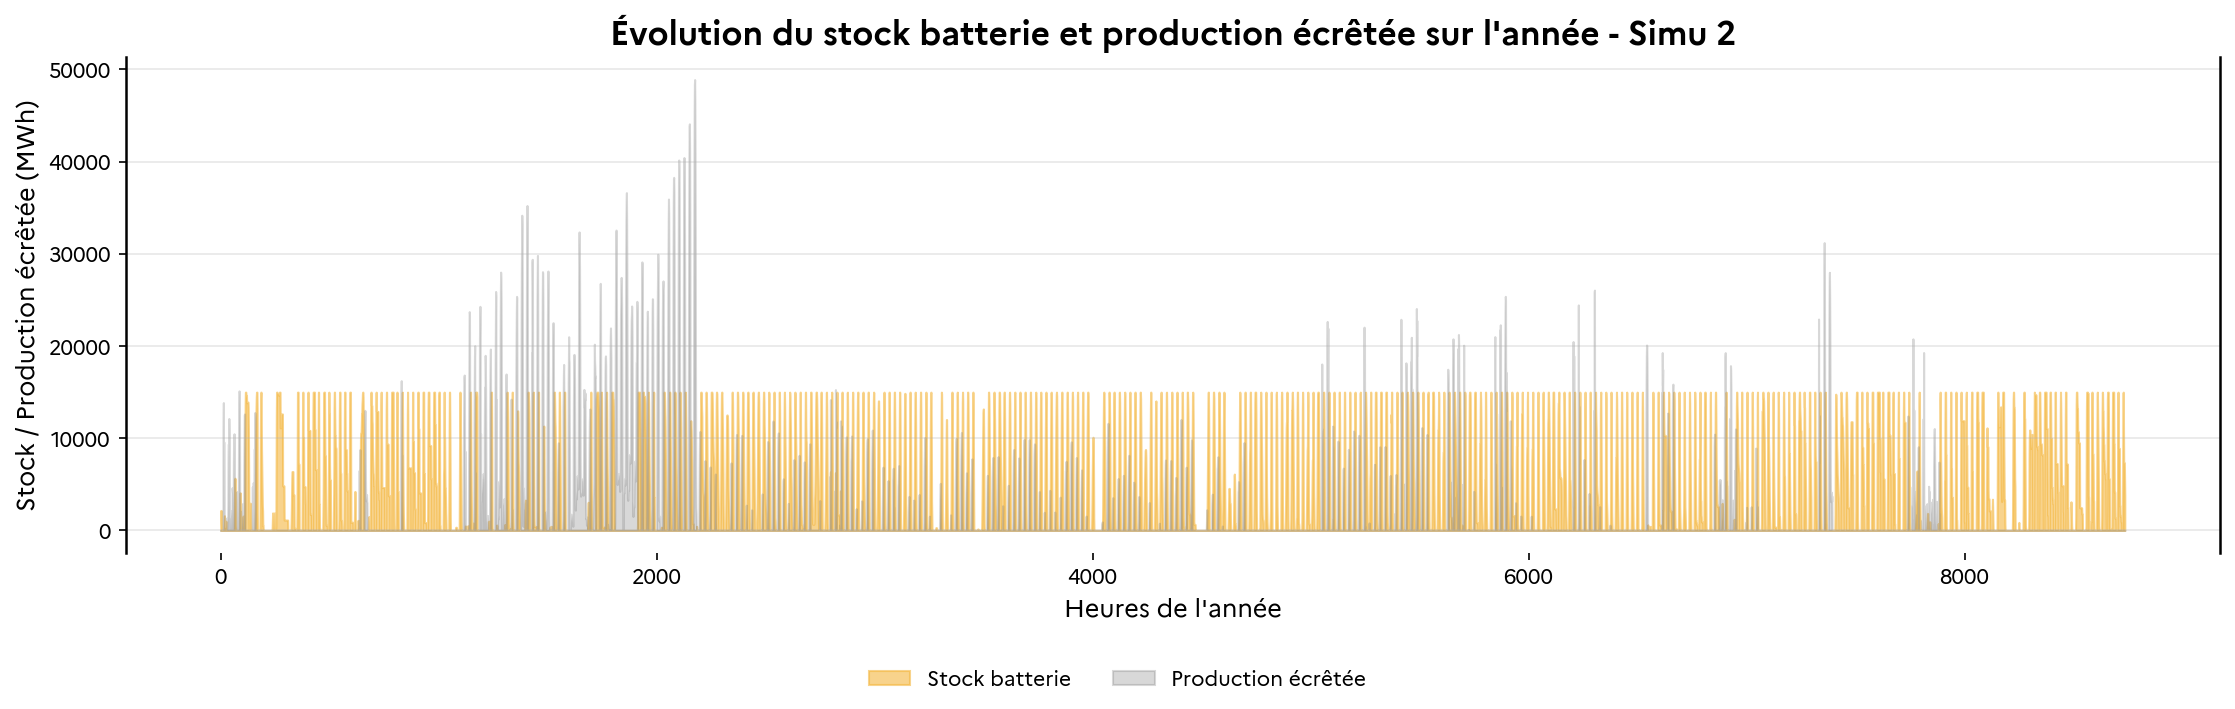

In [ ]:
import matplotlib.pyplot as plt

time = df_global2.index  # index de 0 à 8735

fig, ax1 = plt.subplots(figsize=(15,5), dpi=150)

# -----------------------------
# Axe principal : Stock batterie + Production écrêtée
# -----------------------------
ax1.fill_between(time, 0, df_global2["Battery_stock"], color='#f4b740', alpha=0.6, label="Stock batterie")
ax1.fill_between(time, 0, df_global2["Exces"], color='gray', alpha=0.3, label="Production écrêtée")
ax1.set_xlabel("Heures de l'année")
ax1.set_ylabel("Stock / Production écrêtée (MWh)")

# -----------------------------
# Style minimaliste
# -----------------------------
ax1.grid(axis="y", alpha=0.3)
ax1.set_facecolor("white")
for spine in ax1.spines.values():
    spine.set_visible(False)  # supprime tous les cadres
ax1.spines["left"].set_visible(True)
ax1.spines["left"].set_linewidth(1.2)
ax1.spines["right"].set_visible(True)
ax1.spines["right"].set_linewidth(1.2)

# -----------------------------
# Légende centrée en bas
# -----------------------------
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)

plt.title(f"Évolution du stock batterie et production écrêtée sur l'année - {name_simu_2}")
plt.tight_layout(rect=[0, 0.08, 1, 0.95])  # laisse de la place pour la légende
plt.show()

## **4. Hydraulique**

**SIMU 1**

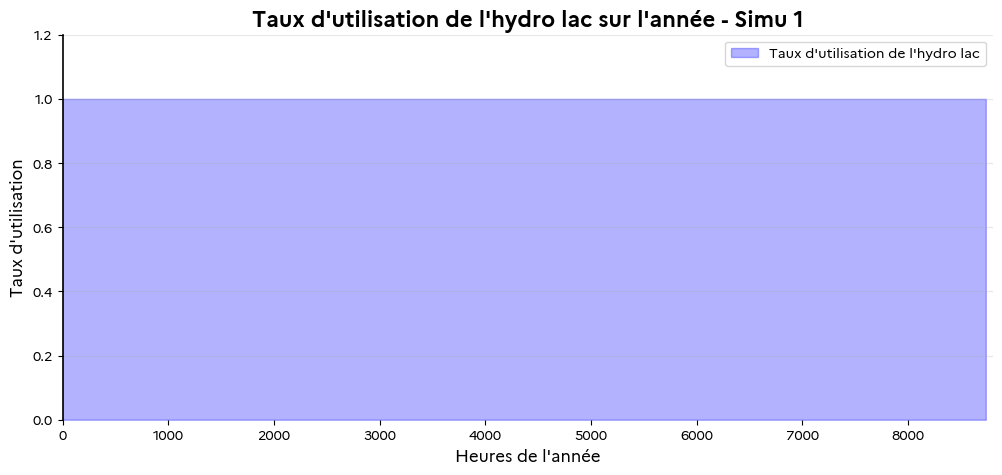

In [ ]:


plt.figure(figsize=(12,5))

ax = plt.gca()  # récupère l'axe courant

# Plot
ax.fill_between(time,0,df_global1["Hydro_lac_utilization_rate"],
        color='blue', alpha=0.3, label="Taux d'utilisation de l'hydro lac")

# Labels et titre
ax.set_xlabel("Heures de l'année")
ax.set_ylabel("Taux d'utilisation")
ax.set_title(f"Taux d'utilisation de l'hydro lac sur l'année - {name_simu_1}")

# Limites
ax.set_ylim(0, 1.2)
ax.set_xlim(0, 8800)

# Grid
ax.grid(axis="y", alpha=0.3)

# Légende
ax.legend(loc="upper right")

# Style minimaliste : enlever tous les cadres sauf gauche
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["left"].set_linewidth(1.2)

plt.show()


**SIMU 2**

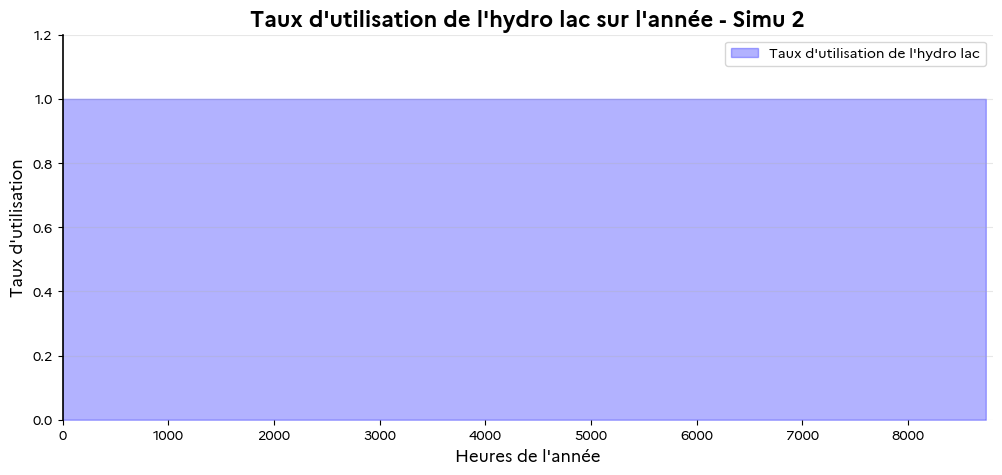

In [ ]:


plt.figure(figsize=(12,5))

ax = plt.gca()  # récupère l'axe courant

# Plot
ax.fill_between(time,0,df_global2["Hydro_lac_utilization_rate"],
        color='blue', alpha=0.3, label="Taux d'utilisation de l'hydro lac")

# Labels et titre
ax.set_xlabel("Heures de l'année")
ax.set_ylabel("Taux d'utilisation")
ax.set_title(f"Taux d'utilisation de l'hydro lac sur l'année - {name_simu_2}")

# Limites
ax.set_ylim(0, 1.2)
ax.set_xlim(0, 8800)

# Grid
ax.grid(axis="y", alpha=0.3)

# Légende
ax.legend(loc="upper right")

# Style minimaliste : enlever tous les cadres sauf gauche
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["left"].set_linewidth(1.2)

plt.show()

## **5. Centrales H2**

In [ ]:

r_CCG_H2 = 0.6 #idem que les CCG_gaz
r_TAC_H2 = 0.4 #idem que les TAC_gaz
r_électrolyse = 0.7

print("Production annuelle écretée", df_global["Exces"].sum(), "\n")
print("Production électricité à partir des centrales H2 annuelle", df_global["H2_CCG"].sum() + df_global["H2_TAC"].sum(), "\n")
print("Quantité hydrogène annuelle pour production électricité", df_global["H2_CCG"].sum()*r_CCG_H2 + df_global["H2_TAC"].sum()*r_TAC_H2, "\n")
print("Taux d'utilisation prod écrêtée pour prod H2", (df_global["H2_CCG"].sum()/(r_électrolyse*r_CCG_H2) + df_global["H2_TAC"].sum()/(r_électrolyse*r_TAC_H2)) / df_global["Exces"].sum() * 100, "%\n")



Production annuelle écretée 88724690.95 

Production électricité à partir des centrales H2 annuelle 7146757.779999999 

Quantité hydrogène annuelle pour production électricité 4010228.8599999994 

Taux d'utilisation prod écrêtée pour prod H2 21.042411982613952 %



Text(0.5, 1.0, "Production d'électricité à partir de l'hydrogène sur l'année")

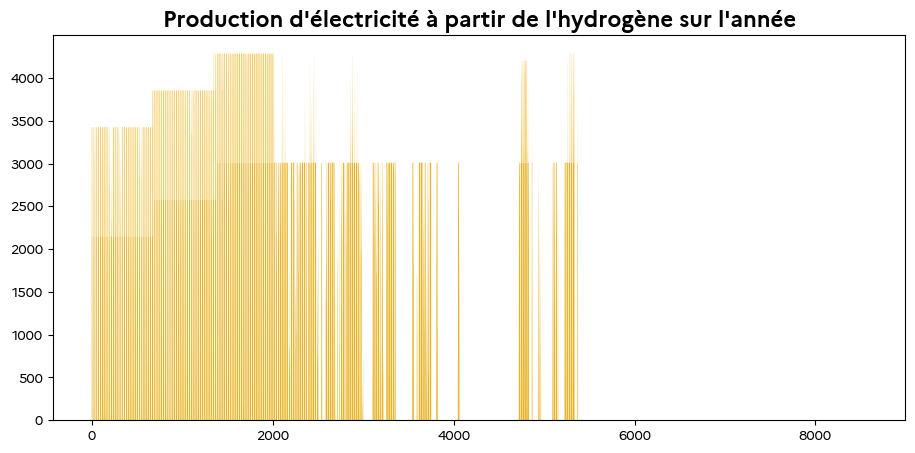

In [ ]:
plt.figure(figsize=(11,5))

# Palette réduite
palette = {
    "H2_CCG": "#e4a701",
    "H2_TAC": "#f0c040"
}

# Colonnes production (positives)
prod_cols = [
    'H2_CCG',
    'H2_TAC'
]

# Pas de charges
charge_cols = []

plt.stackplot(
    df_global.index,
    [df_global[c] for c in prod_cols],
    colors=[palette[c] for c in prod_cols],
    labels=prod_cols,
    alpha=0.85
)
plt.title("Production d'électricité à partir de l'hydrogène sur l'année")

## **6. Défaillance**

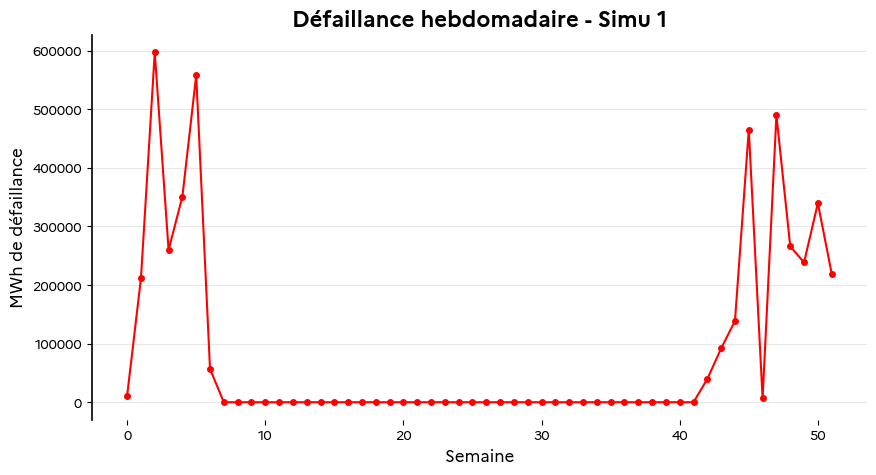

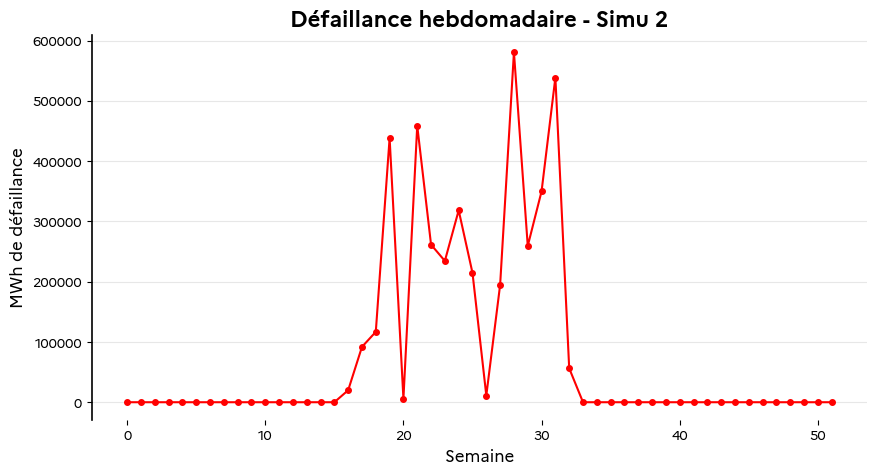

In [ ]:


#### SIMU 1
defaillance1 = df_global1["Defailance"]
weeks = np.arange(len(defaillance1)) // (7*24)
weekly_defaillance1 = [defaillance1[weeks == w].sum() for w in np.unique(weeks)]

plt.figure(figsize=(10,5))
ax = plt.gca()  # récupérer l'axe courant

# Plot avec marqueur plus petit
ax.plot(weekly_defaillance1, marker='o', markersize=4, color='red')  # markersize réduit
ax.set_title(f"Défaillance hebdomadaire - {name_simu_1}")
ax.set_xlabel("Semaine")
ax.set_ylabel("MWh de défaillance")

# Grid horizontale
ax.grid(axis="y", alpha=0.3)

# Style minimaliste : enlever tous les cadres sauf gauche
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["left"].set_linewidth(1.2)


#### SIMU 2
defaillance2 = df_global2["Defailance"]
weeks = np.arange(len(defaillance2)) // (7*24)
weekly_defaillance2 = [defaillance2[weeks == w].sum() for w in np.unique(weeks)]

plt.figure(figsize=(10,5))
ax = plt.gca()  # récupérer l'axe courant

# Plot avec marqueur plus petit
ax.plot(weekly_defaillance2, marker='o', markersize=4, color='red')  # markersize réduit
ax.set_title(f"Défaillance hebdomadaire - {name_simu_2}")
ax.set_xlabel("Semaine")
ax.set_ylabel("MWh de défaillance")

# Grid horizontale
ax.grid(axis="y", alpha=0.3)

# Style minimaliste : enlever tous les cadres sauf gauche
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["left"].set_linewidth(1.2)

plt.show()

## **7. Production écrêtée à l'année**

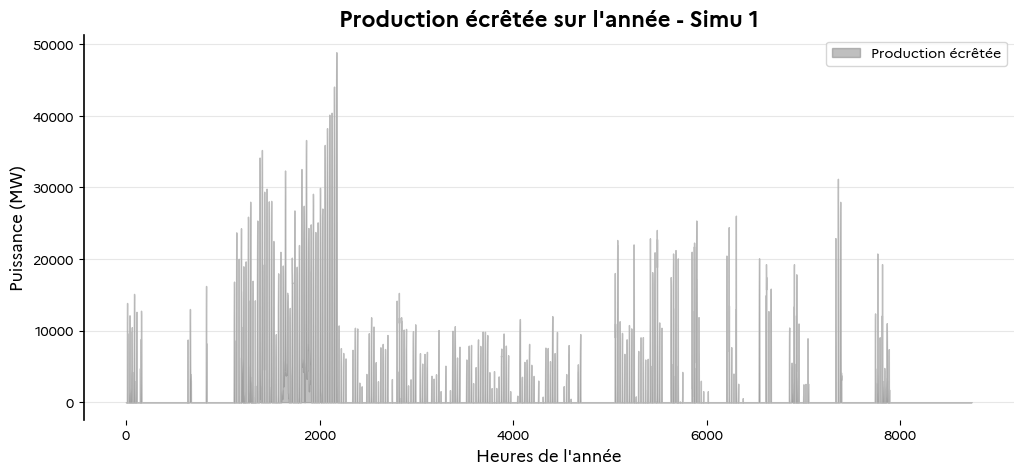

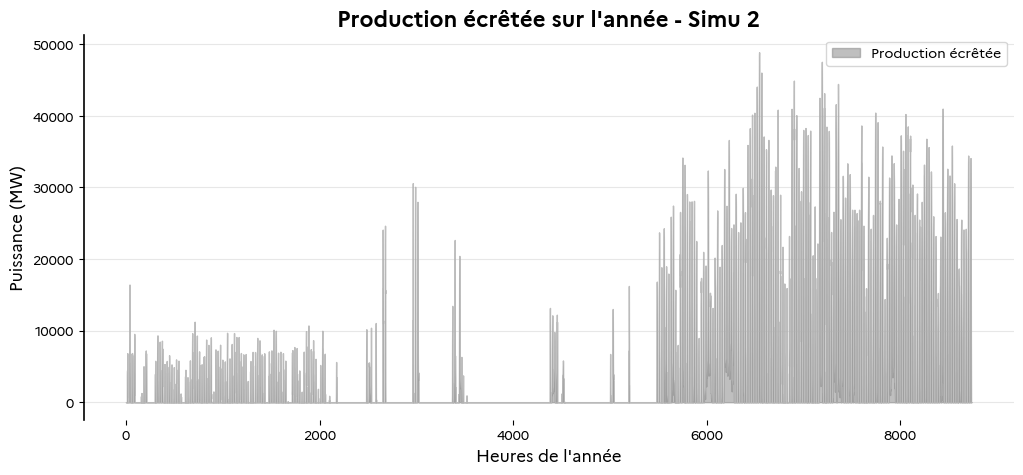

In [ ]:
import matplotlib.pyplot as plt

# -----------------------------
# SIMU 1
# -----------------------------
fig, ax = plt.subplots(figsize=(12,5))
ax.fill_between(df_global1.index, 0, df_global1["Exces"], color='grey', alpha=0.5, label="Production écrêtée")
ax.set_xlabel("Heures de l'année")
ax.set_ylabel("Puissance (MW)")
ax.set_title(f"Production écrêtée sur l'année - {name_simu_1}")

# Grille
ax.grid(axis="y", alpha=0.3)

# Style minimaliste : cadre enlevé sauf gauche
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["left"].set_linewidth(1.2)

# Légende
ax.legend(loc="upper right")

# -----------------------------
# SIMU 2
# -----------------------------
fig, ax = plt.subplots(figsize=(12,5))
ax.fill_between(df_global2.index, 0, df_global2["Exces"], color='grey', alpha=0.5, label="Production écrêtée")
ax.set_xlabel("Heures de l'année")
ax.set_ylabel("Puissance (MW)")
ax.set_title(f"Production écrêtée sur l'année - {name_simu_2}")

# Grille
ax.grid(axis="y", alpha=0.3)

# Style minimaliste : cadre enlevé sauf gauche
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["left"].set_linewidth(1.2)

# Légende
ax.legend(loc="upper right")

plt.show()

### **7. H2**

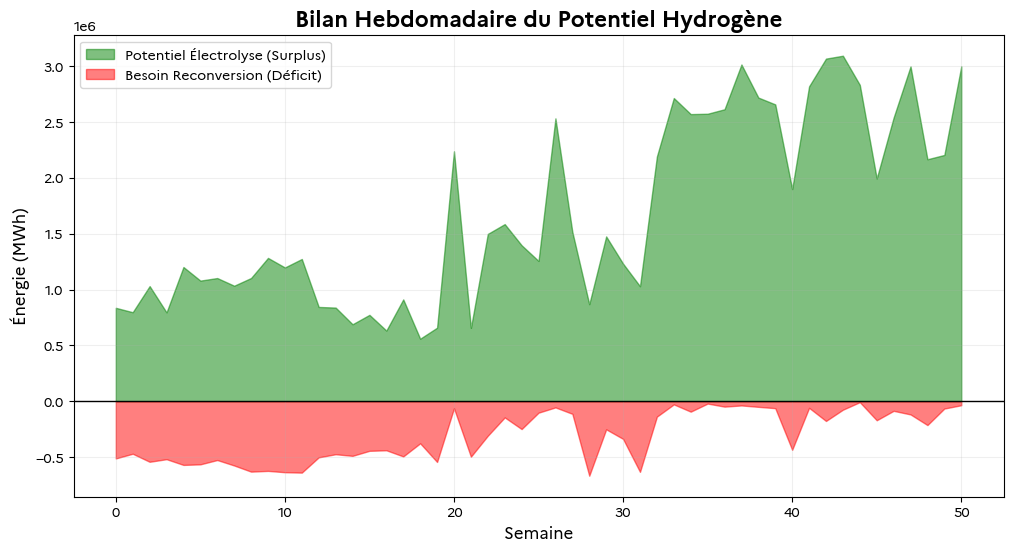

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Calcul des Flux Nets (au pas horaire pour éviter de lisser l'intermittence) ---
# On calcule la production ENR totale par heure
df_global['Total_ENR'] = df_global[['Solar', 'Offshore', 'Onshore']].sum(axis=1)

# On calcule l'écart (Surplus ou Déficit)
df_global['Net_Balance'] = df_global['Total_ENR'] - df_global['Load']

# --- 2. Identification des Potentiels H2 ---
# Potentiel de production : Ce qu'on peut stocker (Surplus ENR)
df_global['H2_Prod_Potential'] = df_global['Net_Balance'].clip(lower=0)

# Besoin de déstockage : Ce qu'on doit fournir (Déficit ENR)
df_global['H2_Generation_Need'] = (-df_global['Net_Balance']).clip(lower=0)

# --- 3. Agrégation Hebdomadaire ---
weekly_h2 = df_global[['H2_Prod_Potential', 'H2_Generation_Need', 'Load']].groupby(df_global.index // (7*24)).sum()

# --- 4. Indicateur d'Agnosticisme (H2-Index) ---
# Ratio : Surplus disponible / Besoin réel. 
# Si > 1, la semaine est potentiellement autonome en H2.
weekly_h2['H2_Autonomy_Ratio'] = weekly_h2['H2_Prod_Potential'] / weekly_h2['H2_Generation_Need']

plt.figure(figsize=(12, 6))
plt.fill_between(weekly_h2.index, weekly_h2['H2_Prod_Potential'], color='green', alpha=0.5, label='Potentiel Électrolyse (Surplus)')
plt.fill_between(weekly_h2.index, -weekly_h2['H2_Generation_Need'], color='red', alpha=0.5, label='Besoin Reconversion (Déficit)')
plt.axhline(0, color='black', lw=1)
plt.title("Bilan Hebdomadaire du Potentiel Hydrogène")
plt.xlabel("Semaine")
plt.ylabel("Énergie (MWh)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))

if "H2_stock" in df_global.columns:
    plt.plot(df_global.index, df_global['H2_stock'], color='blue', label='Stock d\'H2 (MWh)')
    plt.title("Évolution du stock d'hydrogène au cours de l'année")
    plt.xlabel("Heure")
    plt.ylabel("Stock d'hydrogène (MWh)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

<Figure size 1200x600 with 0 Axes>

In [ ]:
if H2_STOCK:

    fig, ax1 = plt.subplots(figsize=(12,5))

    time = df.index

    # Axe principal : Stock STEP et production écrêtée
    ax1.fill_between(time, 0, df["H2_stock"], color='blue', alpha=0.3, label="Stock STEP")
    # ax1.fill_between(time, 0, df["Ecret"], color='gray', alpha=0.3, label="Production écrêtée")
    ax1.set_xlabel("Heure")
    ax1.set_ylabel("Stock (MWh)")
    ax1.legend(loc='upper left')

    # Axe secondaire : Charge et décharge
    ax2 = ax1.twinx()
    ax2.plot(time, -df["H2_CCG"]-df["H2_TAC"], color='red', linewidth=2, label="Production électricité à partir d'H2")
    ax2.plot(time, df["Ecret"], color='green', label="Production écrêtée")
    # ax2.plot(time, df["H2_discharge"], color='red', linewidth=2, label="Décharge H2")
    ax2.set_ylabel("Production électrité / Production écrêtée (MW)")
    ax2.legend(loc='upper right')

    plt.title("Évolution du stock H2 et production écrêtée avec charge/décharge")
    plt.show()